# Winam Gulf water hyacinth spatial-panel test model

This notebook builds a **spatially explicit monthly panel dataset** from already-classified water hyacinth GeoTIFFs in Google Drive.

It is designed as a **test-period prototype**, not the final dissertation model. It:

1. mounts Google Drive;
2. finds classified WH GeoTIFFs for a chosen period;
3. creates fixed 500 m or 1 km grid cells over Winam Gulf;
4. aggregates each classified raster to `grid cell × month`;
5. pulls environmental driver covariates directly from **Google Earth Engine** — rainfall (CHIRPS), wind and air temperature (ERA5), water-surface temperature (MODIS LST), turbidity and chlorophyll-a proxies (Sentinel-2 / Sentinel-3 / MODIS), distance to rivers and shore, and catchment pressure (ESA WorldCover / WorldPop / GHSL) — and optionally merges CSV covariates for layers that have no EE asset (lake level, ENSO/IOD, bathymetry, in-situ nutrients);
6. creates lagged WH-cover and lagged environmental terms;
7. fits a simple two-stage spatial panel model:
   - WH presence/absence;
   - WH proportional cover where WH is present;
8. exports panel tables, predictions and grid outputs.

The intended response variable is **monthly WH proportional cover per spatial unit**, not pixel-level WH occurrence.

The Earth Engine layers, assets and project (`ee-bmillwardsadler1`) match those already used in `Batch_Export.ipynb` and `Classifier_Full_Stack_PostExport_TimeSeries_v4.ipynb`, so the same authenticated Colab runtime can run all three notebooks.

## 1. Install packages

Run this once at the start of a fresh Colab runtime.

In [1]:
# In Colab, uncomment and run this if packages are missing.
# This can take a few minutes.

# earthengine-api and geemap are needed for the Earth Engine covariate extraction
# in section 8. They match the dependencies of the classifier/export notebooks.
!pip -q install rasterio geopandas pyproj shapely fiona pyogrio statsmodels scikit-learn tqdm earthengine-api geemap

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 86.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 114.8 MB/s eta 0:00:00


## 2. Imports and Google Drive mount

In [3]:
from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
import geopandas as gpd

from shapely.geometry import box
from tqdm.auto import tqdm

import rasterio
from rasterio.vrt import WarpedVRT
from rasterio.enums import Resampling
from rasterio.features import rasterize
from rasterio.windows import from_bounds, Window

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
)

import matplotlib.pyplot as plt

# Import the earthengine-api library
import ee

try:
    from google.colab import drive
    drive.mount("/content/drive")
except Exception as e:
    print("Google Drive was not mounted automatically. If running outside Colab, this is expected.")
    print(e)

warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.max_columns", 120)

EE_PROJECT = 'ee-bmillwardsadler1'
ee.Authenticate()
ee.Initialize(project=EE_PROJECT)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 3. User configuration

Edit this cell first.

Important assumptions:

- By default this notebook now reads the **classified GeoTIFFs and run logs produced by `Classifier_Full_Stack_PostExport_TimeSeries_v4.ipynb`**.
- `WH_CLASS_VALUES` is set to `[2]`, matching the classifier notebook's `FLOATING_CLASS_CODE` for floating plants / water hyacinth.
- `CLASSIFIER_SENSOR_FILTER` and `CLASSIFIER_PRODUCT_FILTER` choose which classifier output becomes the panel response. The default uses the S2 Route B model output only, so S1, rule-based rasters, and probability rasters are not accidentally averaged into the same monthly response.
- If you want to run the panel model from a manually curated folder instead, set `USE_CLASSIFIER_RUN_LOG = False` and point `CLASSIFIED_TIF_DIR` at that folder.
- The default grid CRS is **EPSG:32736**, UTM Zone 36S, which is suitable for the Winam Gulf area south of the equator.
- The default AOI is the same broad Winam Gulf rectangle used in your previous GEE workflow.


In [4]:
# ---------------------------------------------------------------------
# Paths
# ---------------------------------------------------------------------

# These defaults match Classifier_Full_Stack_PostExport_TimeSeries_v4.ipynb:
#   DRIVE_ROOT / "outputs" / "full_stack_batch"
CLASSIFIER_BATCH_OUTPUT_DIR = Path("/content/drive/MyDrive/Winam_RF_Training_Data/outputs/full_stack_batch")
CLASSIFIER_TABLE_DIR = CLASSIFIER_BATCH_OUTPUT_DIR / "tables"
CLASSIFIED_TIF_DIR = CLASSIFIER_BATCH_OUTPUT_DIR / "classified_geotiffs"
CLASSIFIER_RUN_LOG_GLOB = "winam_full_stack_run_log_*.csv"

OUTPUT_DIR = Path("/content/drive/MyDrive/WH_spatial_panel_test")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Prefer the classifier notebook's run log because it records exactly which
# classified rasters were generated/reused for each sensor and date window.
# Set False to discover classified GeoTIFFs directly from CLASSIFIED_TIF_DIR.
USE_CLASSIFIER_RUN_LOG = True

# Classifier-output selection. Defaults intentionally keep a single response per
# month by using only S2 model classifications. Use None to include all sensors,
# or set e.g. ["S1"] if you want the SCC/S1 panel instead.
CLASSIFIER_SENSOR_FILTER = ["S2"]       # None, ["S2"], ["S1"], or ["S2", "S1"]
CLASSIFIER_PRODUCT_FILTER = "model"     # "model", "rules", or "all"
PREFER_PATCH_CLEANED_S1 = True           # run-log model paths already point to patch-cleaned files when enabled

# Optional monthly environmental covariates.
# Expected format: one row per month, with a column called 'month'.
# Example columns:
# month,rainfall_mm,wind_speed_ms,lake_level_m,turbidity,chl_a
ENV_MONTHLY_CSV = None
# ENV_MONTHLY_CSV = Path("/content/drive/MyDrive/WH_drivers/monthly_covariates.csv")

# Optional spatial covariates by grid_id.
# Expected format: one row per grid_id, with a column called 'grid_id'.
# Example columns:
# grid_id,dist_river_m,fetch_m,depth_m,shelter_index
SPATIAL_COVARIATES_CSV = None
# SPATIAL_COVARIATES_CSV = Path("/content/drive/MyDrive/WH_drivers/grid_spatial_covariates.csv")

# ---------------------------------------------------------------------
# Test period
# ---------------------------------------------------------------------

TEST_START = "2021-01-01"
TEST_END = "2021-12-31"

# ---------------------------------------------------------------------
# Spatial design
# ---------------------------------------------------------------------

# Use 500 for a more detailed panel, or 1000 for a simpler/coarser test.
# 1000 m is recommended when USE_EARTH_ENGINE is True, because the per-cell
# Earth Engine reductions scale with the number of grid cells.
CELL_SIZE_M = 500

# UTM Zone 36S. Suitable for Winam Gulf because it is just south of the equator.
PANEL_CRS = "EPSG:32736"

# Broad Winam Gulf AOI in WGS84: min_lon, min_lat, max_lon, max_lat
# This matches the `winam` rectangle used in Batch_Export.ipynb.
AOI_BBOX_WGS84 = (34.0, -0.55, 34.9, 0.0)

# ---------------------------------------------------------------------
# Classified raster settings
# ---------------------------------------------------------------------

# Classifier_Full_Stack_PostExport_TimeSeries_v4.ipynb writes floating plants /
# WH-like vegetation as class code 2 (FLOATING_CLASS_CODE = 2). This is the
# response class aggregated into WH cover by the panel model.
WH_CLASS_VALUES = [2]

# The classifier notebook writes NODATA_VALUE = 255. Keep it here even if a
# GeoTIFF's nodata metadata is missing.
EXTRA_NODATA_VALUES = [255]

# Valid classifier classes. S2 uses 0-3; S1/SCC uses 0-2. Including 3 is safe for
# S1 because it simply will not occur.
VALID_CLASS_VALUES = [0, 1, 2, 3]

# Minimum valid pixels in a cell-month for that observation to be retained.
MIN_VALID_PIXELS_PER_CELL_MONTH = 10

# How to combine duplicate classified GeoTIFFs in the same month.
# With the default classifier filters, duplicates usually mean multiple snapshots
# in the same month. Options: "mean", "max"
DUPLICATE_MONTH_METHOD = "mean"

# ---------------------------------------------------------------------
# Model settings
# ---------------------------------------------------------------------

TRAIN_FRACTION = 0.75
RANDOM_STATE = 42

# Fraction of the TRAIN months held out as a validation block used only to tune
# the presence probability threshold. The final TEST months are never used here.
VALIDATION_FRACTION = 0.25

# --- WH presence (Stage 1) target definition ---------------------------------
# Define WH "present" using an ecologically meaningful threshold rather than any
# non-zero pixel. If PRESENCE_AREA_HA_THRESHOLD is set it takes precedence;
# otherwise a fractional-cover threshold is used.
PRESENCE_COVER_THRESHOLD = 0.01      # >= 1% of the valid cell area is WH
PRESENCE_AREA_HA_THRESHOLD = None    # e.g. 0.5 to require >= 0.5 ha of WH instead

# Presence probability-threshold tuning. The threshold that maximises this metric
# on the validation block is selected by default.
PRESENCE_THRESHOLD_METRIC = "f1"
# A higher-recall threshold is also reported if its precision stays above this.
PRESENCE_MIN_PRECISION_FOR_RECALL = 0.5

# --- Habitat / valid-cell filters (applied before modelling) -----------------
# MIN_VALID_PIXELS_PER_CELL_MONTH is defined above with the raster settings.
MIN_VALID_FRACTION_PER_CELL_MONTH = None   # e.g. 0.5 to require >=50% valid cell area
REQUIRE_EVER_WET_OR_EVER_OBSERVED = True   # keep only cells ever validly observed

# ---------------------------------------------------------------------
# Earth Engine environmental covariates
# ---------------------------------------------------------------------

# Master switch. When True, section 8 pulls environmental driver covariates
# directly from Google Earth Engine for each grid cell / month. When False, the
# notebook keeps its original behaviour and uses only the optional CSVs above.
USE_EARTH_ENGINE = True

# Cloud project used for ee.Initialize. Matches Batch_Export.ipynb and
# Classifier_Full_Stack_PostExport_TimeSeries_v4.ipynb.
EE_PROJECT = "ee-bmillwardsadler1"

# Run ee.Authenticate() automatically if ee.Initialize fails the first time on a
# fresh runtime. Set False if you authenticate Earth Engine some other way.
EE_AUTHENTICATE = True

# Per-driver switches. Turn heavy collections (Sentinel-2/3) off for a quick
# test while keeping the cheap climate layers. Each maps to a row of the
# recommended environmental-driver table.
EE_LAYERS = {
    "rainfall_chirps":    True,   # CHIRPS daily -> monthly total + antecedent sums
    "rainfall_era5":      False,  # ERA5 hourly total precipitation (secondary)
    "wind_era5":          True,   # ERA5 hourly 10 m u/v wind -> speed/direction/axis
    "air_temp_era5":      True,   # ERA5 hourly 2 m air temperature
    "water_temp_modis":   True,   # MODIS LST (MOD11A2) day LST over water
    "chl_modis":          False,  # OFF: chlorophyll-a is sourced from Sentinel-3 OLCI
    "waterquality_s2":    True,   # Sentinel-2 turbidity (NDTI + red); chl-a -> Sentinel-3
    "waterquality_s3":    True,   # Sentinel-3 OLCI chl-a (MCI/MPH; Kravitz et al. 2020)
    "river_distance":     True,   # distance to HydroSHEDS rivers
    "shore_distance":     True,   # distance to shore + openness (JRC GSW)
    "catchment_pressure": True,   # ESA WorldCover fractions, WorldPop, GHSL built-up
}

# Which Sentinel-2 water-quality proxies to produce (subset of {"chla", "turbidity"}).
# Chlorophyll-a is retrieved from Sentinel-3 OLCI (see below), so the Sentinel-2 layer
# is limited to turbidity. Add "chla" to also produce the Sentinel-2 NDCI chl-a proxy.
EE_S2_PRODUCTS = {"turbidity"}

# Antecedent rainfall windows (days) summed up to the end of each month.
EE_RAIN_ANTECEDENT_DAYS = [30, 90]

# Bay-axis bearing (degrees clockwise from north) used to resolve the monthly
# wind vector into along-axis and cross-axis components. Winam Gulf opens to the
# main lake roughly to the west/south-west, so its long axis is approximately
# E-W; positive along-axis wind points eastward, into the gulf.
EE_BAY_AXIS_BEARING_DEG = 90.0

# JRC Global Surface Water occurrence threshold (%) used to define water for the
# water-quality reductions and the shoreline geometry. Higher = more permanent
# water. (Batch_Export.ipynb uses 5 for an inclusive export mask; a higher value
# here keeps water-quality proxies over genuinely open water.)
EE_WATER_OCCURRENCE_THRESHOLD = 30

# Sentinel-2 granule cloud prefilter (CLOUDY_PIXEL_PERCENTAGE) before SCL masking.
EE_S2_CLOUD_PCT = 70

# Single scale (m) for the AOI-mean monthly climate reductions. The climate
# datasets are coarse (CHIRPS ~5 km, ERA5 ~28 km, MODIS ~1-4 km) relative to the
# gulf, so an AOI mean at 1 km is appropriate and fast.
EE_CLIMATE_AOI_SCALE = 1000

# Buffer (m) around each grid cell used for the catchment-pressure layers
# (land cover, population, built-up), representing local catchment influence.
EE_CATCHMENT_BUFFER_M = 2000

# Representative year for WorldPop (annual; available 2000-2021).
EE_STATIC_YEAR = 2020

# reduceRegions tiling. Larger tileScale reduces "User memory limit exceeded".
EE_TILE_SCALE = 4

# Grid cells per getInfo request for the per-cell reductions. Lower this if
# requests time out; raise it to issue fewer, larger requests.
EE_MAX_CELLS_PER_REQUEST = 1500

# --- Sentinel-3 OLCI chlorophyll-a (Kravitz et al. 2020) ---
# Kravitz, J., Matthews, M., Bernard, S., Griffith, D. (2020). Application of
# Sentinel 3 OLCI for chl-a retrieval over small inland water targets: successes
# and challenges. Remote Sensing of Environment, 237, 111562.
# https://doi.org/10.1016/j.rse.2019.111562
#
# GEE's COPERNICUS/S3/OLCI carries only TOA radiances + quality_flags; the
# per-pixel observation geometry and meteorology are absent (Warren et al. 2021,
# Remote Sensing 13:1098), so the paper's BRR and 6SV1 atmospheric corrections
# cannot be run inside GEE. Kravitz et al. show their MCI/MPH band-difference
# algorithms are robust to atmospheric correction and give TOA-reflectance
# calibrations (their Table B.1). The notebook computes OLCI TOA reflectance and
# applies:
#   - MCI on TOA reflectance (their best TOA method, R2 = 0.53);
#   - MPH (best overall, R2 = 0.55; only a BRR calibration exists, applied to TOA
#     reflectance here as a documented approximation).
# Use {"mci"} for the single most defensible product, or {"mci", "mph"} for both.
EE_S3_PRODUCTS = {"mci", "mph"}

# Quadratic chl-a calibrations chl = a0*X^2 + a1*X + a2 (Kravitz et al. 2020, Table B.1).
EE_S3_CALIB = {
    "mci": (-93927.30, 7700.85, 16.62),    # Source "TOA Ref", model MCI
    "mph": (-169671.35, 10815.89, 7.54),   # Source "BRR", model MPH (best overall)
}

# Plausible range (mg/m3) used to clamp the retrieved chl-a.
EE_S3_CHLA_CLAMP = (0.0, 1000.0)

# Nominal OLCI top-of-atmosphere solar irradiance E0 (W m-2 um-1; Thuillier 2003)
# for the radiance->reflectance conversion (GEE lacks per-pixel solar flux).
EE_OLCI_E0 = {"Oa08": 1523.6, "Oa10": 1480.0, "Oa11": 1403.0, "Oa12": 1294.0, "Oa18": 935.0}

# Per-band OLCI radiance scale factors (gee:scale in the GEE COPERNICUS/S3/OLCI
# catalogue). The OLCI images carry no per-band "*_radiance_scale" property, so
# these published constants convert the stored DN bands to TOA radiance.
EE_OLCI_RADIANCE_SCALE = {"Oa08": 0.00876539, "Oa10": 0.00773378, "Oa11": 0.00675523,
                          "Oa12": 0.0071996, "Oa18": 0.00549962}

## 4. Helper functions

In [5]:
def parse_month_from_filename(path):
    """
    Extract a monthly timestamp from a GeoTIFF filename.

    Handles common patterns:
    - YYYY-MM-DD
    - YYYY_MM_DD
    - YYYY-MM
    - YYYY_MM
    - YYYYMMDD
    - YYYYMM

    If the name contains a date range, the first date is used.
    """
    name = Path(path).stem

    patterns = [
        r"(?P<year>20\d{2})[-_](?P<month>\d{2})[-_](?P<day>\d{2})",
        r"(?P<year>20\d{2})(?P<month>\d{2})(?P<day>\d{2})",
        r"(?P<year>20\d{2})[-_](?P<month>\d{2})",
        r"(?P<year>20\d{2})(?P<month>\d{2})",
    ]

    for pat in patterns:
        m = re.search(pat, name)
        if m:
            year = int(m.group("year"))
            month = int(m.group("month"))
            return pd.Timestamp(year=year, month=month, day=1)

    return pd.NaT


def _normalise_classifier_sensor(sensor):
    if pd.isna(sensor):
        return None
    sensor = str(sensor).upper()
    if sensor in {"S1", "S1_SCC", "SCC"}:
        return "S1"
    if sensor == "S2":
        return "S2"
    return sensor


def _classifier_sensor_from_path(path):
    stem = Path(path).stem.lower()
    if stem.startswith("winam_s2_predictors_"):
        return "S2"
    if stem.startswith("winam_s1_predictors_") or stem.startswith("winam_s1_scc_predictors_"):
        return "S1"
    return None


def _classifier_product_from_path(path):
    stem = Path(path).stem.lower()
    if stem.endswith("_proba") or "_proba" in stem:
        return "probability"
    if stem.endswith("_local_rules"):
        return "rules"
    if "_local_" in stem:
        return "model"
    return "unknown"


def _path_is_classifier_classification(path):
    product = _classifier_product_from_path(path)
    return product in {"model", "rules"}


def _passes_classifier_filters(sensor, product):
    sensor = _normalise_classifier_sensor(sensor)
    if CLASSIFIER_SENSOR_FILTER is not None:
        allowed = {_normalise_classifier_sensor(s) for s in CLASSIFIER_SENSOR_FILTER}
        if sensor not in allowed:
            return False

    if CLASSIFIER_PRODUCT_FILTER != "all" and product != CLASSIFIER_PRODUCT_FILTER:
        return False

    return True


def _latest_classifier_run_log(table_dir=CLASSIFIER_TABLE_DIR, pattern=CLASSIFIER_RUN_LOG_GLOB):
    table_dir = Path(table_dir)
    candidates = sorted(table_dir.glob(pattern), key=lambda p: p.stat().st_mtime)
    return candidates[-1] if candidates else None


def _records_from_classifier_run_log(run_log_path):
    """Read classifier-notebook outputs from its batch run log."""
    run_log_path = Path(run_log_path)
    log = pd.read_csv(run_log_path)
    required = {"sensor", "start_date", "end_date", "status"}
    missing = required.difference(log.columns)
    if missing:
        raise ValueError(f"Classifier run log is missing required columns {sorted(missing)}: {run_log_path}")

    path_columns = []
    if CLASSIFIER_PRODUCT_FILTER in {"model", "all"} and "model_classification_tif" in log.columns:
        path_columns.append(("model_classification_tif", "model"))
    if CLASSIFIER_PRODUCT_FILTER in {"rules", "all"} and "rule_classification_tif" in log.columns:
        path_columns.append(("rule_classification_tif", "rules"))
    if not path_columns:
        raise ValueError(
            "No usable classification path columns were found in the classifier run log. "
            "Expected model_classification_tif and/or rule_classification_tif."
        )

    records = []
    completed = log[log["status"].astype(str).str.lower().eq("completed")].copy()
    for _, row in completed.iterrows():
        sensor = _normalise_classifier_sensor(row["sensor"])
        for col, product in path_columns:
            raw_path = row.get(col, "")
            if pd.isna(raw_path) or str(raw_path).strip() == "":
                continue
            path = Path(str(raw_path))
            if not _passes_classifier_filters(sensor, product):
                continue
            if product == "model" and not PREFER_PATCH_CLEANED_S1 and path.stem.endswith("_patch_cleaned"):
                uncleaned = path.with_name(path.name.replace("_patch_cleaned", ""))
                if uncleaned.exists():
                    path = uncleaned
            if not path.exists():
                print(f"Skipping missing classifier output from run log: {path}")
                continue
            month = pd.Timestamp(row["start_date"]).to_period("M").to_timestamp()
            records.append({
                "path": path,
                "month": month,
                "sensor": sensor,
                "product": product,
                "start_date": row["start_date"],
                "end_date": row["end_date"],
                "source_run_log": str(run_log_path),
            })
    return records


def _records_from_classifier_folder(folder):
    """Fallback discovery for classifier GeoTIFF folders when no run log is used."""
    folder = Path(folder)
    files = sorted(list(folder.rglob("*.tif")) + list(folder.rglob("*.tiff")))
    records = []
    for fp in files:
        if not _path_is_classifier_classification(fp):
            continue
        product = _classifier_product_from_path(fp)
        sensor = _classifier_sensor_from_path(fp)
        if not _passes_classifier_filters(sensor, product):
            continue
        month = parse_month_from_filename(fp)
        if pd.isna(month):
            continue
        records.append({
            "path": fp,
            "month": month,
            "sensor": sensor,
            "product": product,
            "start_date": None,
            "end_date": None,
            "source_run_log": None,
        })
    return records


def find_classified_tifs(folder, start, end):
    """
    Find classifier-notebook classified GeoTIFFs and retain those whose month
    falls within the requested test period.

    When USE_CLASSIFIER_RUN_LOG is True, the latest run log in CLASSIFIER_TABLE_DIR
    is used so probability rasters, stale ad-hoc files, and unselected sensors or
    products are not accidentally included in the panel response. If no run log is
    available, discovery falls back to CLASSIFIED_TIF_DIR.
    """
    folder = Path(folder)
    start = pd.Timestamp(start).to_period("M").to_timestamp()
    end = pd.Timestamp(end).to_period("M").to_timestamp()

    records = []
    run_log_path = None
    if USE_CLASSIFIER_RUN_LOG:
        run_log_path = _latest_classifier_run_log()
        if run_log_path is not None:
            print(f"Using classifier run log: {run_log_path}")
            records = _records_from_classifier_run_log(run_log_path)
        else:
            print(f"No classifier run log found in {CLASSIFIER_TABLE_DIR}; falling back to folder discovery.")

    if run_log_path is None:
        records = _records_from_classifier_folder(folder)

    records = [r for r in records if start <= r["month"] <= end]
    out = pd.DataFrame(records)
    if len(out) == 0:
        raise FileNotFoundError(
            f"No classifier GeoTIFFs found in {folder} between {start.date()} and {end.date()} "
            f"for sensor filter {CLASSIFIER_SENSOR_FILTER} and product filter {CLASSIFIER_PRODUCT_FILTER}. "
            "Run Classifier_Full_Stack_PostExport_TimeSeries_v4.ipynb first, or adjust the classifier-output filters."
        )

    out = out.drop_duplicates(["path", "month", "sensor", "product"]).sort_values(
        ["month", "sensor", "product", "path"]
    ).reset_index(drop=True)
    return out


def create_grid_from_bbox(aoi_bbox_wgs84, cell_size_m, panel_crs):
    """
    Create square grid cells over the AOI bounding box.

    The grid is generated in a projected CRS so each cell has a meaningful metric area.
    """
    aoi_wgs84 = gpd.GeoDataFrame(
        {"name": ["aoi"]},
        geometry=[box(*aoi_bbox_wgs84)],
        crs="EPSG:4326",
    )

    aoi_proj = aoi_wgs84.to_crs(panel_crs)
    xmin, ymin, xmax, ymax = aoi_proj.total_bounds

    xmin = np.floor(xmin / cell_size_m) * cell_size_m
    ymin = np.floor(ymin / cell_size_m) * cell_size_m
    xmax = np.ceil(xmax / cell_size_m) * cell_size_m
    ymax = np.ceil(ymax / cell_size_m) * cell_size_m

    xs = np.arange(xmin, xmax, cell_size_m)
    ys = np.arange(ymin, ymax, cell_size_m)

    cells = []
    for x in xs:
        for y in ys:
            geom = box(x, y, x + cell_size_m, y + cell_size_m)
            if geom.intersects(aoi_proj.geometry.iloc[0]):
                cells.append(geom)

    grid = gpd.GeoDataFrame(
        {"grid_id": np.arange(len(cells), dtype=np.int32)},
        geometry=cells,
        crs=panel_crs,
    )

    # Retain simple centroid-based spatial controls.
    cent = grid.geometry.centroid
    grid["x_km"] = cent.x / 1000.0
    grid["y_km"] = cent.y / 1000.0
    grid["cell_area_m2"] = grid.geometry.area

    return grid


def clamp_window(win, width, height):
    """
    Clamp a rasterio window to raster bounds.
    """
    col_off = max(0, int(np.floor(win.col_off)))
    row_off = max(0, int(np.floor(win.row_off)))
    col_max = min(width, int(np.ceil(win.col_off + win.width)))
    row_max = min(height, int(np.ceil(win.row_off + win.height)))

    if col_max <= col_off or row_max <= row_off:
        return None

    return Window(col_off, row_off, col_max - col_off, row_max - row_off)


def aggregate_one_raster_to_grid(
    tif_path,
    month,
    grid_gdf,
    panel_crs,
    wh_class_values,
    extra_nodata_values=None,
    valid_class_values=None,
):
    """
    Aggregate one classified WH GeoTIFF to the fixed grid.

    The raster is read through a WarpedVRT in the panel CRS, so pixel area is
    approximately metric and consistent across rasters.
    """
    extra_nodata_values = [] if extra_nodata_values is None else list(extra_nodata_values)
    wh_class_values = np.array(wh_class_values)

    with rasterio.open(tif_path) as src:
        vrt_kwargs = {
            "crs": panel_crs,
            "resampling": Resampling.nearest,
        }

        if src.nodata is not None:
            vrt_kwargs["nodata"] = src.nodata

        with WarpedVRT(src, **vrt_kwargs) as vrt:
            grid_bounds = grid_gdf.total_bounds
            raw_win = from_bounds(*grid_bounds, transform=vrt.transform)
            win = clamp_window(raw_win, vrt.width, vrt.height)

            if win is None:
                return pd.DataFrame()

            arr = vrt.read(1, window=win)
            transform = vrt.window_transform(win)

            # Rasterize grid IDs onto the same raster grid.
            shapes = ((geom, int(gid)) for geom, gid in zip(grid_gdf.geometry, grid_gdf["grid_id"]))
            id_arr = rasterize(
                shapes=shapes,
                out_shape=arr.shape,
                transform=transform,
                fill=-1,
                dtype="int32",
            )

            valid = id_arr >= 0

            if src.nodata is not None:
                valid &= arr != src.nodata

            if len(extra_nodata_values) > 0:
                valid &= ~np.isin(arr, np.array(extra_nodata_values))

            if valid_class_values is not None:
                valid &= np.isin(arr, np.array(valid_class_values))

            wh = valid & np.isin(arr, wh_class_values)

            valid_ids = id_arr[valid].astype(np.int32)
            wh_ids = id_arr[wh].astype(np.int32)

            n_cells = int(grid_gdf["grid_id"].max()) + 1
            valid_counts = np.bincount(valid_ids, minlength=n_cells)
            wh_counts = np.bincount(wh_ids, minlength=n_cells)

            pixel_area_m2 = abs(transform.a * transform.e)

            df = pd.DataFrame({
                "grid_id": np.arange(n_cells, dtype=np.int32),
                "month": pd.Timestamp(month),
                "valid_pixels": valid_counts.astype(np.int64),
                "wh_pixels": wh_counts.astype(np.int64),
            })

            df = df[df["valid_pixels"] > 0].copy()
            df["valid_area_m2"] = df["valid_pixels"] * pixel_area_m2
            df["wh_area_m2"] = df["wh_pixels"] * pixel_area_m2
            df["wh_cover"] = df["wh_area_m2"] / df["valid_area_m2"]
            df["source_file"] = Path(tif_path).name

            return df


def load_monthly_covariates(csv_path):
    """
    Load monthly covariates from CSV.

    Required column:
    - month

    The month column can be YYYY-MM, YYYY-MM-DD, or another pandas-parseable date.
    """
    df = pd.read_csv(csv_path)
    if "month" not in df.columns:
        raise ValueError("ENV_MONTHLY_CSV must contain a 'month' column.")

    df["month"] = pd.to_datetime(df["month"]).dt.to_period("M").dt.to_timestamp()
    return df


def clean_feature_columns(df, candidate_cols):
    """
    Keep numeric feature columns that are not entirely missing and not constant.
    """
    keep = []
    for col in candidate_cols:
        if col not in df.columns:
            continue
        if not pd.api.types.is_numeric_dtype(df[col]):
            continue
        non_missing = df[col].dropna()
        if len(non_missing) == 0:
            continue
        if non_missing.nunique() <= 1:
            continue
        keep.append(col)
    return keep


In [6]:
# =====================================================================
# Earth Engine covariate helpers
# =====================================================================
# These functions pull the environmental driver layers that have usable
# Google Earth Engine assets and reduce them onto the spatial-panel grid.
#
# Coverage of the recommended environmental-driver table:
#   Rainfall ............ CHIRPS daily (UCSB-CHG/CHIRPS/DAILY); optional ERA5
#   Wind ................ ERA5 hourly 10 m u/v (ECMWF/ERA5/HOURLY)
#   Air temperature ..... ERA5 hourly 2 m (ECMWF/ERA5/HOURLY)
#   Water temperature ... MODIS LST 8-day day (MODIS/061/MOD11A2), water-masked
#   Turbidity/TSS ....... Sentinel-2 NDTI + red reflectance (water-masked)
#   Chlorophyll-a ....... Sentinel-2 NDCI (water-masked) and MODIS-Aqua chlor_a;
#                         optional Sentinel-3 OLCI MCI bloom index
#   River influence ..... distance to HydroSHEDS rivers (WWF/HydroSHEDS/v1/FreeFlowingRivers)
#   Shoreline retention . distance to shore + openness (JRC/GSW1_4/GlobalSurfaceWater)
#   Catchment pressure .. ESA WorldCover v200, WorldPop GP 100m, GHSL P2023A built-up
#
# Layers WITHOUT a standard EE asset are still handled by the optional CSVs in
# section 9: lake level (DAHITI / Hydroweb / G-REALM altimetry), ENSO/IOD
# indices, bathymetry/depth, and in-situ nutrients.
# =====================================================================

try:
    import ee
except Exception:
    ee = None

try:
    from shapely.geometry import mapping as _shapely_mapping
except Exception:
    _shapely_mapping = None

_EE_STATE = {"initialised": False}


def initialize_earth_engine(project=None, authenticate=None):
    """Initialise Earth Engine, authenticating on first use if needed."""
    if ee is None:
        raise ImportError("earthengine-api is not installed. Run the install cell first.")
    project = project or EE_PROJECT
    if authenticate is None:
        authenticate = EE_AUTHENTICATE
    if _EE_STATE["initialised"]:
        return ee
    try:
        ee.Initialize(project=project)
    except Exception:
        if authenticate:
            ee.Authenticate()
        ee.Initialize(project=project)
    _EE_STATE["initialised"] = True
    print(f"Earth Engine initialised on project: {project}")
    return ee


def ee_aoi_geometry(bbox=None):
    """AOI as an ee.Geometry rectangle in EPSG:4326 (matches AOI_BBOX_WGS84)."""
    bbox = AOI_BBOX_WGS84 if bbox is None else bbox
    return ee.Geometry.Rectangle(list(bbox), proj="EPSG:4326", geodesic=False)


def ee_water_mask01(aoi):
    """Mask that keeps water (JRC GSW occurrence >= threshold) and drops land."""
    return (
        ee.Image("JRC/GSW1_4/GlobalSurfaceWater")
        .select("occurrence")
        .gte(EE_WATER_OCCURRENCE_THRESHOLD)
        .selfMask()
        .clip(aoi)
    )


def mask_s2_sr(img):
    """Sentinel-2 SCL cloud/shadow/snow mask (same logic as Batch_Export.ipynb)."""
    scl = img.select("SCL")
    mask = (
        scl.neq(3)     # cloud shadow
        .And(scl.neq(8))    # medium-probability cloud
        .And(scl.neq(9))    # high-probability cloud
        .And(scl.neq(10))   # thin cirrus
        .And(scl.neq(11))   # snow/ice
    )
    return img.updateMask(mask)


def _masked_band_template(band_names):
    """A fully masked multi-band image, used so monthly composites always carry
    their band schema even when a month has no imagery (keeps reduceRegions from
    failing on a zero-band image)."""
    n = len(band_names)
    return (
        ee.Image.constant([0] * n).rename(band_names).toFloat()
        .updateMask(ee.Image.constant(0))
    )


# ---------------------------------------------------------------------
# AOI-mean monthly climate covariates (rainfall, wind, temperature, chl-a)
# ---------------------------------------------------------------------

def climate_image_for_month(month_start):
    """Multi-band monthly climate image for an ee.Date month start."""
    start = ee.Date(month_start)
    end = start.advance(1, "month")
    aoi = ee_aoi_geometry()
    bands = []

    if EE_LAYERS.get("rainfall_chirps"):
        chirps = ee.ImageCollection("UCSB-CHG/CHIRPS/DAILY").select("precipitation")
        bands.append(chirps.filterDate(start, end).sum().rename("rain_chirps_mm"))
        for d in EE_RAIN_ANTECEDENT_DAYS:
            d = int(d)
            bands.append(
                chirps.filterDate(end.advance(-d, "day"), end).sum().rename(f"rain_chirps_{d}d_mm")
            )

    if EE_LAYERS.get("rainfall_era5"):
        era5p = ee.ImageCollection("ECMWF/ERA5/HOURLY").select("total_precipitation_hourly")
        bands.append(
            era5p.filterDate(start, end).sum().multiply(1000.0).rename("rain_era5_mm")
        )

    if EE_LAYERS.get("wind_era5"):
        era5 = ee.ImageCollection("ECMWF/ERA5/HOURLY").filterDate(start, end)
        u = era5.select("u_component_of_wind_10m").mean().rename("wind_u_ms")
        v = era5.select("v_component_of_wind_10m").mean().rename("wind_v_ms")
        spd = (
            era5.map(lambda im: im.expression(
                "sqrt(u*u + v*v)",
                {"u": im.select("u_component_of_wind_10m"),
                 "v": im.select("v_component_of_wind_10m")},
            ).rename("s")).mean().rename("wind_speed_ms")
        )
        bands.extend([u, v, spd])

    if EE_LAYERS.get("air_temp_era5"):
        era5t = ee.ImageCollection("ECMWF/ERA5/HOURLY").filterDate(start, end).select("temperature_2m")
        bands.append(era5t.mean().subtract(273.15).rename("air_temp_c"))

    if EE_LAYERS.get("water_temp_modis"):
        lst = (
            ee.ImageCollection("MODIS/061/MOD11A2").filterDate(start, end)
            .select("LST_Day_1km").mean().multiply(0.02).subtract(273.15)
            .updateMask(ee_water_mask01(aoi)).rename("water_temp_c")
        )
        bands.append(lst)

    if EE_LAYERS.get("chl_modis"):
        # MODIS-Aqua ocean colour ends 2022-02-28; covers the default 2021 test.
        chl = (
            ee.ImageCollection("NASA/OCEANDATA/MODIS-Aqua/L3SMI").filterDate(start, end)
            .select("chlor_a").mean().rename("chl_modis_mg_m3")
        )
        bands.append(chl)

    return ee.Image.cat(bands)


def aoi_monthly_dataframe(image_for_month, months, scale, aoi):
    """AOI-mean of a per-month image, returned as a month-indexed DataFrame."""
    month_millis = [int(pd.Timestamp(m).value // 10**6) for m in months]

    def per_month(ms):
        ms = ee.Number(ms)
        img = image_for_month(ee.Date(ms))
        stats = img.reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=aoi,
            scale=scale,
            maxPixels=1e13,
            tileScale=EE_TILE_SCALE,
            bestEffort=True,
        )
        return ee.Feature(None, stats).set("month_millis", ms)

    fc = ee.FeatureCollection(ee.List(month_millis).map(per_month))
    info = fc.getInfo()
    rows = []
    for feat in info["features"]:
        props = dict(feat["properties"])
        ms = props.pop("month_millis")
        props["month"] = pd.Timestamp(int(ms), unit="ms").to_period("M").to_timestamp()
        rows.append(props)
    return pd.DataFrame(rows).sort_values("month").reset_index(drop=True)


def add_wind_components(monthly_df):
    """Derive wind direction and bay-axis components from monthly mean u/v."""
    if monthly_df is None or not {"wind_u_ms", "wind_v_ms"}.issubset(monthly_df.columns):
        return monthly_df
    theta = np.radians(EE_BAY_AXIS_BEARING_DEG)
    u = monthly_df["wind_u_ms"]
    v = monthly_df["wind_v_ms"]
    # Direction the wind blows TOWARDS, degrees clockwise from north.
    monthly_df["wind_dir_to_deg"] = np.degrees(np.arctan2(u, v)) % 360
    # Components relative to the bay axis (positive along-axis = towards bearing).
    monthly_df["wind_axis_comp_ms"] = u * np.sin(theta) + v * np.cos(theta)
    monthly_df["wind_cross_comp_ms"] = u * np.cos(theta) - v * np.sin(theta)
    return monthly_df


# ---------------------------------------------------------------------
# Per grid cell / month water-quality covariates (Sentinel-2 / Sentinel-3)
# ---------------------------------------------------------------------

def gdf_to_ee_fc(gdf_wgs84):
    """Build an ee.FeatureCollection from a WGS84 GeoDataFrame chunk."""
    feats = []
    for row in gdf_wgs84.itertuples(index=False):
        geom = ee.Geometry(_shapely_mapping(row.geometry), proj="EPSG:4326", geodesic=False)
        feats.append(ee.Feature(geom, {"grid_id": int(row.grid_id)}))
    return ee.FeatureCollection(feats)


def reduce_image_over_cells(image, grid_wgs84, reducer, scale, buffer_m=0, extra_props=None):
    """reduceRegions an image over grid cells, chunked, returned as a DataFrame."""
    rows = []
    n = len(grid_wgs84)
    for start in range(0, n, EE_MAX_CELLS_PER_REQUEST):
        chunk = grid_wgs84.iloc[start:start + EE_MAX_CELLS_PER_REQUEST]
        fc = gdf_to_ee_fc(chunk)
        if buffer_m and buffer_m > 0:
            fc = fc.map(lambda f: f.buffer(buffer_m))
        reduced = image.reduceRegions(
            collection=fc, reducer=reducer, scale=scale, tileScale=EE_TILE_SCALE
        )
        info = reduced.getInfo()
        for feat in info["features"]:
            props = dict(feat["properties"])
            props.pop("system:index", None)
            if extra_props:
                props.update(extra_props)
            rows.append(props)
    return pd.DataFrame(rows)


def s2_waterquality_image(month_start, aoi):
    """Monthly median Sentinel-2 water-quality proxies, masked to water.

    EE_S2_PRODUCTS selects which proxies are produced:
      - "turbidity": NDTI + red reflectance
      - "chla":      NDCI (red-edge chlorophyll-a proxy)
    Chlorophyll-a is sourced from Sentinel-3 OLCI by default, so "chla" is off.
    """
    start = pd.Timestamp(month_start)
    end = start + pd.offsets.MonthBegin(1)
    bands = []
    if "chla" in EE_S2_PRODUCTS:
        bands.append("chl_ndci_s2")
    if "turbidity" in EE_S2_PRODUCTS:
        bands += ["turb_ndti_s2", "red_reflectance_s2"]
    coll = (
        ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
        .filterBounds(aoi)
        .filterDate(str(start.date()), str(end.date()))
        .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", EE_S2_CLOUD_PCT))
        .map(mask_s2_sr)
    )

    def add_wq(img):
        b = img.select(["B3", "B4", "B5"]).multiply(0.0001)
        out = []
        if "chla" in EE_S2_PRODUCTS:
            out.append(b.normalizedDifference(["B5", "B4"]).rename("chl_ndci_s2"))     # red-edge chl-a proxy
        if "turbidity" in EE_S2_PRODUCTS:
            out.append(b.normalizedDifference(["B4", "B3"]).rename("turb_ndti_s2"))     # turbidity proxy
            out.append(b.select("B4").rename("red_reflectance_s2"))                     # turbidity magnitude
        return ee.Image.cat(out)

    # Prepend a fully masked template so the composite always carries its band
    # schema, even for a month with no usable Sentinel-2 imagery.
    wq_coll = ee.ImageCollection([_masked_band_template(bands)]).merge(coll.map(add_wq))
    return wq_coll.median().updateMask(ee_water_mask01(aoi)).clip(aoi)


def _olci_cos_solar_zenith(img):
    """Per-pixel cos(solar zenith) for an OLCI image, from acquisition time and
    pixel location (NOAA approximation). GEE's OLCI asset has no geometry
    tie-points, so the solar geometry needed to convert radiance to reflectance
    is reconstructed here."""
    date = ee.Date(img.get("system:time_start"))
    doy = ee.Number(date.getRelative("day", "year")).add(1)
    hour = ee.Number(date.get("hour")).add(ee.Number(date.get("minute")).divide(60.0))
    gamma = doy.subtract(1).add(hour.subtract(12).divide(24.0)).multiply(2.0 * np.pi / 365.0)
    cg, sg = gamma.cos(), gamma.sin()
    c2g, s2g = gamma.multiply(2).cos(), gamma.multiply(2).sin()
    c3g, s3g = gamma.multiply(3).cos(), gamma.multiply(3).sin()
    decl = (ee.Number(0.006918)
            .subtract(cg.multiply(0.399912)).add(sg.multiply(0.070257))
            .subtract(c2g.multiply(0.006758)).add(s2g.multiply(0.000907))
            .subtract(c3g.multiply(0.002697)).add(s3g.multiply(0.00148)))
    eqtime = ee.Number(229.18).multiply(
        ee.Number(0.000075).add(cg.multiply(0.001868)).subtract(sg.multiply(0.032077))
        .subtract(c2g.multiply(0.014615)).subtract(s2g.multiply(0.040849)))
    lonlat = ee.Image.pixelLonLat()
    lat = lonlat.select("latitude").multiply(np.pi / 180.0)
    lon = lonlat.select("longitude")
    tst = lon.multiply(4).add(hour.multiply(60)).add(eqtime)            # true solar time (min)
    ha = tst.divide(4).subtract(180).multiply(np.pi / 180.0)            # hour angle (rad)
    cosz = (lat.sin().multiply(decl.sin())
            .add(lat.cos().multiply(ha.cos()).multiply(decl.cos())))
    return cosz.clamp(0.05, 1.0)


def s3_chla_image(month_start, aoi):
    """Monthly Sentinel-3 OLCI chlorophyll-a (mg/m3) from band-difference
    algorithms, following Kravitz et al. (2020), Remote Sensing of Environment
    237:111562, https://doi.org/10.1016/j.rse.2019.111562.

    GEE's COPERNICUS/S3/OLCI provides only TOA radiances + quality_flags (no
    observation geometry or meteorology), so the paper's best atmospheric
    corrections (BRR, 6SV1) cannot be reproduced here. Kravitz et al. show the
    MCI and MPH band-difference algorithms are robust to atmospheric correction
    (baseline subtraction removes the smooth atmospheric signal) and publish
    TOA-reflectance calibrations (their Table B.1). We therefore compute OLCI TOA
    reflectance and apply MCI (their best TOA method) and MPH (best overall; its
    only calibration is BRR, applied here to TOA reflectance as an approximation).
    The MPH peak-switching index originates with Matthews et al. (2012), RSE
    124:637-652. Per-band GEE radiance scaling is used as published, which is
    known to deviate slightly from the original product (Warren et al. 2021,
    Remote Sensing 13:1098), so the mg/m3 values are indicative.
    """
    start = pd.Timestamp(month_start)
    end = start + pd.offsets.MonthBegin(1)
    # OLCI bands used: Oa08=665, Oa10=681.25, Oa11=708.75, Oa12=753.75, Oa18=885 nm.
    bands = ["Oa08", "Oa10", "Oa11", "Oa12", "Oa18"]

    def to_reflectance(img):
        cosz = _olci_cos_solar_zenith(img)
        out = []
        for b in bands:
            rad = img.select(b + "_radiance").multiply(ee.Number(EE_OLCI_RADIANCE_SCALE[b]))
            refl = rad.multiply(np.pi).divide(ee.Number(EE_OLCI_E0[b])).divide(cosz).rename(b)
            out.append(refl)
        return ee.Image.cat(out)

    coll = (
        ee.ImageCollection("COPERNICUS/S3/OLCI")
        .filterBounds(aoi)
        .filterDate(str(start.date()), str(end.date()))
        .map(to_reflectance)
    )
    # Monthly median reflectance; masked template keeps the band schema if empty.
    refl = ee.ImageCollection([_masked_band_template(bands)]).merge(coll).median()
    R665, R681, R709, R754, R885 = (refl.select(b) for b in bands)

    out_bands = []
    if "mci" in EE_S3_PRODUCTS:
        # MCI: peak at 709, baseline 681<->754 (Kravitz et al. 2020, eq. 3).
        mci = R709.subtract(R681).subtract(
            R754.subtract(R681).multiply((708.75 - 681.25) / (753.75 - 681.25)))
        a0, a1, a2 = EE_S3_CALIB["mci"]
        out_bands.append(
            mci.pow(2).multiply(a0).add(mci.multiply(a1)).add(a2)
            .clamp(EE_S3_CHLA_CLAMP[0], EE_S3_CHLA_CLAMP[1]).rename("chl_mci_s3"))
    if "mph" in EE_S3_PRODUCTS:
        # MPH: peak switches among 681/709/754, baseline 665<->885 (Matthews et al. 2012).
        peak = R681.max(R709).max(R754)
        lam = ee.Image(753.75).where(peak.eq(R709), 708.75).where(peak.eq(R681), 681.25)
        mph = peak.subtract(R665).subtract(
            R885.subtract(R665).multiply(lam.subtract(665.0).divide(885.0 - 665.0)))
        a0, a1, a2 = EE_S3_CALIB["mph"]
        out_bands.append(
            mph.pow(2).multiply(a0).add(mph.multiply(a1)).add(a2)
            .clamp(EE_S3_CHLA_CLAMP[0], EE_S3_CHLA_CLAMP[1]).rename("chl_mph_s3"))

    return ee.Image.cat(out_bands).updateMask(ee_water_mask01(aoi)).clip(aoi)


# ---------------------------------------------------------------------
# Static per grid cell covariates (river/shore geometry, catchment pressure)
# ---------------------------------------------------------------------

def static_cell_mean_image(aoi):
    """Image of cell-mean static layers: distances and shoreline openness."""
    bands = []
    if EE_LAYERS.get("river_distance"):
        rivers = ee.FeatureCollection("WWF/HydroSHEDS/v1/FreeFlowingRivers").filterBounds(aoi.buffer(50000))
        bands.append(rivers.distance(50000).rename("dist_river_m"))
    if EE_LAYERS.get("shore_distance"):
        occ = ee.Image("JRC/GSW1_4/GlobalSurfaceWater").select("occurrence").unmask(0)
        land01 = occ.gte(EE_WATER_OCCURRENCE_THRESHOLD).Not()
        bands.append(land01.distance(ee.Kernel.euclidean(20000, "meters")).rename("dist_shore_m"))
        bands.append(
            occ.reduceNeighborhood(reducer=ee.Reducer.mean(), kernel=ee.Kernel.circle(5000, "meters"))
            .rename("openness_index")
        )
    if not bands:
        return None
    return ee.Image.cat(bands).clip(aoi)


def landcover_fraction_image(aoi):
    """ESA WorldCover binary class layers; reduced with mean over a buffer -> fraction."""
    wc = ee.ImageCollection("ESA/WorldCover/v200").filterBounds(aoi).mosaic().select("Map")
    crop = wc.eq(40).rename("frac_cropland")
    urban = wc.eq(50).rename("frac_urban")
    wetland = wc.eq(90).rename("frac_wetland")
    return ee.Image.cat([crop, urban, wetland]).toFloat().clip(aoi)


def population_builtup_image(aoi):
    """WorldPop population and GHSL built-up surface; reduced with sum over a buffer."""
    pop = (
        ee.ImageCollection("WorldPop/GP/100m/pop")
        .filter(ee.Filter.eq("year", int(EE_STATIC_YEAR)))
        .filterBounds(aoi).mosaic().select("population").rename("pop_count")
    )
    built = (
        ee.ImageCollection("JRC/GHSL/P2023A/GHS_BUILT_S")
        .filterDate("2020-01-01", "2021-01-01").first().select("built_surface").rename("ghsl_built_m2")
    )
    return ee.Image.cat([pop, built]).clip(aoi)


# ---------------------------------------------------------------------
# Orchestrator
# ---------------------------------------------------------------------

def extract_ee_covariates(grid_gdf, months):
    """Extract every enabled Earth Engine covariate onto the panel grid.

    Returns (monthly_df, cellmonth_df, static_df, registry) where:
      - monthly_df is keyed by 'month' (AOI-mean climate),
      - cellmonth_df is keyed by ['grid_id', 'month'] (S2/S3 water quality),
      - static_df is keyed by 'grid_id' (river/shore/catchment),
      - registry lists the covariate columns in each group.
    """
    initialize_earth_engine()
    aoi = ee_aoi_geometry()
    grid_wgs84 = grid_gdf[["grid_id", "geometry"]].to_crs("EPSG:4326")
    months = sorted(
        pd.to_datetime(pd.Series(list(months))).dt.to_period("M").dt.to_timestamp().unique()
    )

    registry = {"monthly": [], "cellmonth": [], "static": []}
    monthly_df = cellmonth_df = static_df = None

    # --- AOI-mean monthly climate ---
    climate_keys = ["rainfall_chirps", "rainfall_era5", "wind_era5",
                    "air_temp_era5", "water_temp_modis", "chl_modis"]
    if any(EE_LAYERS.get(k) for k in climate_keys):
        print("Extracting AOI-mean monthly climate covariates (CHIRPS / ERA5 / MODIS) ...")
        monthly_df = aoi_monthly_dataframe(climate_image_for_month, months, EE_CLIMATE_AOI_SCALE, aoi)
        monthly_df = add_wind_components(monthly_df)
        registry["monthly"] = [c for c in monthly_df.columns if c != "month"]
        print("  monthly climate columns:", registry["monthly"])

    # --- Per cell / month water quality ---
    cm_parts = []
    if EE_LAYERS.get("waterquality_s2") and EE_S2_PRODUCTS:
        print("Extracting Sentinel-2 water-quality proxies per cell and month ...")
        frames = []
        for m in tqdm(months, desc="S2 NDCI/NDTI"):
            img = s2_waterquality_image(m, aoi)
            frames.append(reduce_image_over_cells(img, grid_wgs84, ee.Reducer.median(), 20, extra_props={"month": m}))
        cm_parts.append(pd.concat(frames, ignore_index=True))
    if EE_LAYERS.get("waterquality_s3") and EE_S3_PRODUCTS:
        print("Extracting Sentinel-3 OLCI chl-a (MCI/MPH; Kravitz et al. 2020) per cell and month ...")
        frames = []
        for m in tqdm(months, desc="S3 chl-a"):
            img = s3_chla_image(m, aoi)
            frames.append(reduce_image_over_cells(img, grid_wgs84, ee.Reducer.mean(), 300, extra_props={"month": m}))
        cm_parts.append(pd.concat(frames, ignore_index=True))
    if cm_parts:
        cellmonth_df = cm_parts[0]
        for part in cm_parts[1:]:
            cellmonth_df = cellmonth_df.merge(part, on=["grid_id", "month"], how="outer")
        cellmonth_df["month"] = pd.to_datetime(cellmonth_df["month"]).dt.to_period("M").dt.to_timestamp()
        registry["cellmonth"] = [c for c in cellmonth_df.columns if c not in ("grid_id", "month")]
        print("  per-cell/month columns:", registry["cellmonth"])

    # --- Static per cell ---
    static_parts = []
    cell_img = static_cell_mean_image(aoi)
    if cell_img is not None:
        print("Extracting static distance/openness covariates per cell ...")
        static_parts.append(reduce_image_over_cells(cell_img, grid_wgs84, ee.Reducer.mean(), 90))
    if EE_LAYERS.get("catchment_pressure"):
        print("Extracting catchment-pressure covariates per cell (WorldCover / WorldPop / GHSL) ...")
        frac_img = landcover_fraction_image(aoi)
        static_parts.append(
            reduce_image_over_cells(frac_img, grid_wgs84, ee.Reducer.mean(), 10, buffer_m=EE_CATCHMENT_BUFFER_M)
        )
        count_img = population_builtup_image(aoi)
        static_parts.append(
            reduce_image_over_cells(count_img, grid_wgs84, ee.Reducer.sum(), 100, buffer_m=EE_CATCHMENT_BUFFER_M)
        )
    if static_parts:
        static_df = static_parts[0]
        for part in static_parts[1:]:
            static_df = static_df.merge(part, on="grid_id", how="outer")
        static_df = static_df.groupby("grid_id", as_index=False).first()
        registry["static"] = [c for c in static_df.columns if c != "grid_id"]
        print("  static columns:", registry["static"])

    return monthly_df, cellmonth_df, static_df, registry

## 5. Find classifier-output GeoTIFFs for the test period

This step uses the classifier notebook's latest batch run log when available. The default filters select only S2 model-classification rasters, excluding S1, paper-rule rasters, and `_proba` probability rasters so the monthly response is not mixed across products.


In [7]:
tif_index = find_classified_tifs(CLASSIFIED_TIF_DIR, TEST_START, TEST_END)

print(f"Found {len(tif_index)} classifier GeoTIFF(s).")
display(tif_index.head(20))

if {"sensor", "product"}.issubset(tif_index.columns):
    print("Classifier outputs selected for the panel:")
    display(tif_index.groupby(["sensor", "product"]).size().rename("n_geotiffs").reset_index())

dupes = tif_index.groupby("month").size()
dupes = dupes[dupes > 1]
if len(dupes) > 0:
    print("Months with multiple GeoTIFFs. These will be combined later using:", DUPLICATE_MONTH_METHOD)
    display(dupes)


Using classifier run log: /content/drive/MyDrive/Winam_RF_Training_Data/outputs/full_stack_batch/tables/winam_full_stack_run_log_route_b_s1_scc_spatialcv_proba_v3.csv
Found 48 classifier GeoTIFF(s).


,path,month,sensor,product,start_date,end_date,source_run_log
0,/content/drive/MyDrive/Winam_RF_Training_Data/...,2021-01-01,S2,model,2021-01-01,2021-01-02,/content/drive/MyDrive/Winam_RF_Training_Data/...
1,/content/drive/MyDrive/Winam_RF_Training_Data/...,2021-01-01,S2,model,2021-01-06,2021-01-07,/content/drive/MyDrive/Winam_RF_Training_Data/...
2,/content/drive/MyDrive/Winam_RF_Training_Data/...,2021-01-01,S2,model,2021-01-21,2021-01-22,/content/drive/MyDrive/Winam_RF_Training_Data/...
3,/content/drive/MyDrive/Winam_RF_Training_Data/...,2021-01-01,S2,model,2021-01-26,2021-01-27,/content/drive/MyDrive/Winam_RF_Training_Data/...
4,/content/drive/MyDrive/Winam_RF_Training_Data/...,2021-01-01,S2,model,2021-01-31,2021-02-01,/content/drive/MyDrive/Winam_RF_Training_Data/...
5,/content/drive/MyDrive/Winam_RF_Training_Data/...,2021-02-01,S2,model,2021-02-05,2021-02-06,/content/drive/MyDrive/Winam_RF_Training_Data/...
6,/content/drive/MyDrive/Winam_RF_Training_Data/...,2021-02-01,S2,model,2021-02-10,2021-02-11,/content/drive/MyDrive/Winam_RF_Training_Data/...
7,/content/drive/MyDrive/Winam_RF_Training_Data/...,2021-02-01,S2,model,2021-02-15,2021-02-16,/content/drive/MyDrive/Winam_RF_Training_Data/...
8,/content/drive/MyDrive/Winam_RF_Training_Data/...,2021-02-01,S2,model,2021-02-25,2021-02-26,/content/drive/MyDrive/Winam_RF_Training_Data/...
9,/content/drive/MyDrive/Winam_RF_Training_Data/...,2021-03-01,S2,model,2021-03-02,2021-03-03,/content/drive/MyDrive/Winam_RF_Training_Data/...


Classifier outputs selected for the panel:


,sensor,product,n_geotiffs
0,S2,model,48


Months with multiple GeoTIFFs. These will be combined later using: mean


,0
month,
2021-01-01,5
2021-02-01,4
2021-03-01,3
2021-04-01,4
2021-05-01,5
2021-06-01,5
2021-07-01,4
2021-08-01,4
2021-09-01,4


## 6. Create the spatial grid

This creates the fixed spatial units used in the panel. For a quick test, `CELL_SIZE_M = 1000` is faster. For a more detailed prototype, use `CELL_SIZE_M = 500`.

Created 24,522 grid cells at 500 m resolution.


,grid_id,geometry,x_km,y_km,cell_area_m2
0,0,"POLYGON ((611500 9939000, 611500 9939500, 6110...",611.25,9939.25,250000.0
1,1,"POLYGON ((611500 9939500, 611500 9940000, 6110...",611.25,9939.75,250000.0
2,2,"POLYGON ((611500 9940000, 611500 9940500, 6110...",611.25,9940.25,250000.0
3,3,"POLYGON ((611500 9940500, 611500 9941000, 6110...",611.25,9940.75,250000.0
4,4,"POLYGON ((611500 9941000, 611500 9941500, 6110...",611.25,9941.25,250000.0


Saved grid to:
/content/drive/MyDrive/WH_spatial_panel_test/winam_grid_500m.gpkg
/content/drive/MyDrive/WH_spatial_panel_test/winam_grid_500m.geojson


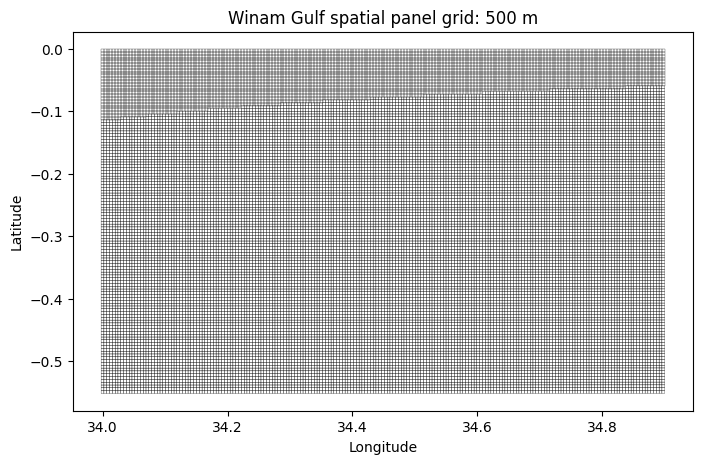

In [8]:
grid = create_grid_from_bbox(AOI_BBOX_WGS84, CELL_SIZE_M, PANEL_CRS)

print(f"Created {len(grid):,} grid cells at {CELL_SIZE_M} m resolution.")
display(grid.head())

grid_path_gpkg = OUTPUT_DIR / f"winam_grid_{CELL_SIZE_M}m.gpkg"
grid_path_geojson = OUTPUT_DIR / f"winam_grid_{CELL_SIZE_M}m.geojson"

grid.to_file(grid_path_gpkg, layer="grid", driver="GPKG")
grid.to_crs("EPSG:4326").to_file(grid_path_geojson, driver="GeoJSON")

print("Saved grid to:")
print(grid_path_gpkg)
print(grid_path_geojson)

ax = grid.to_crs("EPSG:4326").plot(figsize=(8, 6), facecolor="none", edgecolor="black", linewidth=0.2)
ax.set_title(f"Winam Gulf spatial panel grid: {CELL_SIZE_M} m")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.show()

## 7. Aggregate classifier-output WH rasters to the grid

This is the main preprocessing step.

For every selected classifier GeoTIFF, the notebook calculates, for each grid cell:

- valid classified pixel count;
- WH / floating-plant pixel count using `WH_CLASS_VALUES`;
- valid classified area;
- WH area;
- WH proportional cover.

The result is a `grid_id × month` panel with source classifier metadata retained for auditability.


In [9]:
panel_parts = []
metadata_cols = ["sensor", "product", "start_date", "end_date", "source_run_log"]

for row in tqdm(tif_index.itertuples(index=False), total=len(tif_index)):
    df = aggregate_one_raster_to_grid(
        tif_path=row.path,
        month=row.month,
        grid_gdf=grid,
        panel_crs=PANEL_CRS,
        wh_class_values=WH_CLASS_VALUES,
        extra_nodata_values=EXTRA_NODATA_VALUES,
        valid_class_values=VALID_CLASS_VALUES,
    )
    if len(df) > 0:
        row_dict = row._asdict()
        for col in metadata_cols:
            if col in row_dict:
                df[f"source_{col}"] = row_dict[col]
        panel_parts.append(df)

if len(panel_parts) == 0:
    raise RuntimeError("No panel rows were created. Check raster CRS, AOI, class codes and no-data settings.")

panel_raw = pd.concat(panel_parts, ignore_index=True)

print(f"Raw panel rows before duplicate-month handling: {len(panel_raw):,}")
display(panel_raw.head())


  0%|          | 0/48 [00:00<?, ?it/s]

Raw panel rows before duplicate-month handling: 481,863


,grid_id,month,valid_pixels,wh_pixels,valid_area_m2,wh_area_m2,wh_cover,source_file,source_sensor,source_product,source_start_date,source_end_date,source_source_run_log
0,11,2021-01-01,252,0,25200.0,0.0,0.000000,winam_s2_predictors_2021-01-01_to_2021-01-02_l...,S2,model,2021-01-01,2021-01-02,/content/drive/MyDrive/Winam_RF_Training_Data/...
1,12,2021-01-01,237,0,23700.0,0.0,0.000000,winam_s2_predictors_2021-01-01_to_2021-01-02_l...,S2,model,2021-01-01,2021-01-02,/content/drive/MyDrive/Winam_RF_Training_Data/...
2,25,2021-01-01,26,6,2600.0,600.0,0.230769,winam_s2_predictors_2021-01-01_to_2021-01-02_l...,S2,model,2021-01-01,2021-01-02,/content/drive/MyDrive/Winam_RF_Training_Data/...
3,79,2021-01-01,48,0,4800.0,0.0,0.000000,winam_s2_predictors_2021-01-01_to_2021-01-02_l...,S2,model,2021-01-01,2021-01-02,/content/drive/MyDrive/Winam_RF_Training_Data/...
4,83,2021-01-01,108,10,10800.0,1000.0,0.092593,winam_s2_predictors_2021-01-01_to_2021-01-02_l...,S2,model,2021-01-01,2021-01-02,/content/drive/MyDrive/Winam_RF_Training_Data/...


### Combine duplicate observations within the same month

If the classifier output has only one selected raster per month, this step will not change much.

If there are multiple selected snapshots in the same month, the default behaviour is to take the **mean** grid-cell WH cover/area across those rasters. You can change this to `max` in the configuration cell.


In [10]:
if DUPLICATE_MONTH_METHOD not in {"mean", "max"}:
    raise ValueError("DUPLICATE_MONTH_METHOD must be either 'mean' or 'max'.")

source_agg = lambda x: "; ".join(sorted(set(map(str, x.dropna()))))
source_metadata_cols = [c for c in panel_raw.columns if c.startswith("source_")]

if DUPLICATE_MONTH_METHOD == "mean":
    agg_funcs = {
        "valid_pixels": "mean",
        "wh_pixels": "mean",
        "valid_area_m2": "mean",
        "wh_area_m2": "mean",
        "wh_cover": "mean",
        "source_file": source_agg,
    }
elif DUPLICATE_MONTH_METHOD == "max":
    agg_funcs = {
        "valid_pixels": "max",
        "wh_pixels": "max",
        "valid_area_m2": "max",
        "wh_area_m2": "max",
        "wh_cover": "max",
        "source_file": source_agg,
    }

for col in source_metadata_cols:
    agg_funcs[col] = source_agg

panel = (
    panel_raw
    .groupby(["grid_id", "month"], as_index=False)
    .agg(agg_funcs)
)

# Retain only minimally valid cell-months.
panel = panel[panel["valid_pixels"] >= MIN_VALID_PIXELS_PER_CELL_MONTH].copy()

# Merge grid attributes.
grid_attrs = grid.drop(columns="geometry").copy()
panel = panel.merge(grid_attrs, on="grid_id", how="left")

# Basic response variables.
panel["wh_area_ha"] = panel["wh_area_m2"] / 10_000
panel["valid_area_ha"] = panel["valid_area_m2"] / 10_000
# Fractional valid coverage of the nominal cell area (1.0 == fully observed).
# Used by the optional habitat / valid-cell filter before modelling.
panel["valid_fraction"] = (panel["valid_area_m2"] / (CELL_SIZE_M ** 2)).clip(upper=1.0)

# --- WH presence definition --------------------------------------------------
# Previously: panel["wh_present"] = panel["wh_area_m2"] > 0  (any non-zero pixel).
# Now configurable: an area threshold (ha) takes precedence if set, otherwise a
# fractional-cover threshold. See PRESENCE_*_THRESHOLD in the configuration cell.
if PRESENCE_AREA_HA_THRESHOLD is not None:
    panel["wh_present"] = panel["wh_area_ha"] >= PRESENCE_AREA_HA_THRESHOLD
    presence_definition = f"wh_area_ha >= {PRESENCE_AREA_HA_THRESHOLD} ha"
else:
    panel["wh_present"] = panel["wh_cover"] >= PRESENCE_COVER_THRESHOLD
    presence_definition = f"wh_cover >= {PRESENCE_COVER_THRESHOLD:g} (fractional cover)"

print(f"Panel rows after duplicate-month handling and validity filtering: {len(panel):,}")
print(f"Months: {panel['month'].nunique()}")
print(f"Grid cells represented: {panel['grid_id'].nunique()}")

# WH-present prevalence under the chosen definition.
print(f"\nWH presence defined as: {presence_definition}")
print(f"Overall WH-present prevalence: {panel['wh_present'].mean():.4f} "
      f"({int(panel['wh_present'].sum()):,} of {len(panel):,} cell-months)")
print("\nWH-present prevalence by month:")
prevalence_by_month = (
    panel.groupby("month")["wh_present"].agg(["mean", "sum", "size"])
    .rename(columns={"mean": "present_rate", "sum": "n_present", "size": "n_cells"})
)
display(prevalence_by_month)

display(panel.head())


Panel rows after duplicate-month handling and validity filtering: 129,907
Months: 12
Grid cells represented: 10828


,grid_id,month,valid_pixels,wh_pixels,valid_area_m2,wh_area_m2,wh_cover,source_file,source_sensor,source_product,source_start_date,source_end_date,source_source_run_log,x_km,y_km,cell_area_m2,wh_present,wh_area_ha,valid_area_ha
0,0,2021-01-01,713.0,0.000000,71300.0,0.000000,0.00000,winam_s2_predictors_2021-01-21_to_2021-01-22_l...,S2,model,2021-01-21; 2021-01-26; 2021-01-31,2021-01-22; 2021-01-27; 2021-02-01,/content/drive/MyDrive/Winam_RF_Training_Data/...,611.25,9939.25,250000.0,False,0.000000,7.13
1,0,2021-02-01,713.0,5.333333,71300.0,533.333333,0.00748,winam_s2_predictors_2021-02-10_to_2021-02-11_l...,S2,model,2021-02-10; 2021-02-15; 2021-02-25,2021-02-11; 2021-02-16; 2021-02-26,/content/drive/MyDrive/Winam_RF_Training_Data/...,611.25,9939.25,250000.0,True,0.053333,7.13
2,0,2021-03-01,713.0,0.000000,71300.0,0.000000,0.00000,winam_s2_predictors_2021-03-02_to_2021-03-03_l...,S2,model,2021-03-02; 2021-03-07; 2021-03-12,2021-03-03; 2021-03-08; 2021-03-13,/content/drive/MyDrive/Winam_RF_Training_Data/...,611.25,9939.25,250000.0,False,0.000000,7.13
3,0,2021-04-01,713.0,0.000000,71300.0,0.000000,0.00000,winam_s2_predictors_2021-04-01_to_2021-04-02_l...,S2,model,2021-04-01; 2021-04-06; 2021-04-11; 2021-04-26,2021-04-02; 2021-04-07; 2021-04-12; 2021-04-27,/content/drive/MyDrive/Winam_RF_Training_Data/...,611.25,9939.25,250000.0,False,0.000000,7.13
4,0,2021-05-01,713.0,0.000000,71300.0,0.000000,0.00000,winam_s2_predictors_2021-05-06_to_2021-05-07_l...,S2,model,2021-05-06; 2021-05-16; 2021-05-21; 2021-05-26...,2021-05-07; 2021-05-17; 2021-05-22; 2021-05-27...,/content/drive/MyDrive/Winam_RF_Training_Data/...,611.25,9939.25,250000.0,False,0.000000,7.13


### Sensitivity of the WH-present definition to the chosen threshold

The response variable depends strongly on how "present" is defined. The table
below shows how the number of positive cell-months, the positive rate, the mean
WH signal among positives, and the number of months with at least one positive
cell change as the fractional-cover presence threshold is varied. Threshold `0`
reproduces the original "any non-zero WH pixel" definition.


In [ ]:
presence_threshold_grid = [0, 0.001, 0.005, 0.01, 0.02, 0.05]

sensitivity_rows = []
for thr in presence_threshold_grid:
    # thr == 0 reproduces the original "any non-zero WH" definition.
    present = panel["wh_cover"] > 0 if thr == 0 else panel["wh_cover"] >= thr
    n_pos = int(present.sum())
    sensitivity_rows.append({
        "cover_threshold": thr,
        "n_positive_cell_months": n_pos,
        "pct_positive": round(100 * present.mean(), 3),
        "mean_cover_among_pos": round(panel.loc[present, "wh_cover"].mean(), 4) if n_pos else np.nan,
        "mean_area_ha_among_pos": round(panel.loc[present, "wh_area_ha"].mean(), 4) if n_pos else np.nan,
        "n_months_with_positive": int(panel.loc[present, "month"].nunique()),
    })

presence_sensitivity = pd.DataFrame(sensitivity_rows)
print("Sensitivity of WH-present prevalence to the cover threshold:")
display(presence_sensitivity)


## 8. Earth Engine environmental covariate extraction

This step pulls the environmental driver layers that have usable Google Earth Engine assets and reduces them onto the panel. It runs when `USE_EARTH_ENGINE = True` (configured in section 3) and is wrapped in a `try/except` so the notebook still completes if Earth Engine is unavailable.

Three tables are produced:

| Output | Keyed by | Layers |
| --- | --- | --- |
| `ee_monthly_cov` | `month` | Rainfall (CHIRPS, monthly + antecedent sums), wind (ERA5 u/v, speed, direction, bay-axis components), air temperature (ERA5), water-surface temperature (MODIS LST), optional MODIS ocean-colour chlorophyll-a (off by default) |
| `ee_cellmonth_cov` | `grid_id`, `month` | Sentinel-2 **turbidity** (NDTI + red reflectance) proxy; **Sentinel-3 OLCI chlorophyll-a** (mg/m³) via MCI and MPH band-difference algorithms calibrated per Kravitz et al. (2020); all water-masked |
| `ee_static_cov` | `grid_id` | Distance to rivers (HydroSHEDS), distance to shore and openness (JRC GSW), catchment pressure (ESA WorldCover fractions, WorldPop population, GHSL built-up) |

**Resolution strategy.** Reanalysis/coarse climate layers (CHIRPS ~5 km, ERA5 ~28 km, MODIS ~1–4 km) are extracted as **AOI-mean monthly series**, so they enter as month-level covariates. Sentinel-2 water-quality proxies (~20 m) are extracted **per grid cell and month**, because they carry real within-gulf spatial signal. Static layers are extracted **once per cell**.

**Sentinel-3 OLCI chlorophyll-a.** GEE's OLCI asset provides only TOA radiances (no geometry/meteorology tie-points), so the best atmospheric corrections in Kravitz et al. (2020) — BRR and 6SV1 — cannot be reproduced inside GEE. Their key result is that the **MCI and MPH band-difference algorithms are robust to atmospheric correction**, and they publish TOA-reflectance calibrations (Table B.1). The notebook therefore computes OLCI TOA reflectance (nominal solar irradiance + analytically reconstructed solar zenith) and retrieves chl-a with **MCI** (their best TOA method, R²=0.53) and **MPH** (best overall, R²=0.55; its BRR calibration is applied to TOA reflectance as a documented approximation). For publication-grade chl-a, process BRR/6SV externally (SNAP / Py6S) and ingest via the CSV hook in section 9.

**Layers that need a CSV instead (no standard EE asset):** lake level (DAHITI / Hydroweb / G-REALM altimetry), ENSO/IOD indices, bathymetry/depth, and in-situ nutrients (TN, TP, DIN, SRP). Supply these through `ENV_MONTHLY_CSV` / `SPATIAL_COVARIATES_CSV` in section 9.

> The first run on a fresh Colab runtime triggers `ee.Authenticate()`. Per-cell reductions scale with the number of grid cells, so prefer `CELL_SIZE_M = 1000` for Earth Engine test runs, or turn off `waterquality_s2`/`waterquality_s3` in `EE_LAYERS` for the quickest pass.

In [11]:
# Initialise the EE covariate containers so later cells work even when
# USE_EARTH_ENGINE is False or extraction fails.
ee_monthly_cov = None
ee_cellmonth_cov = None
ee_static_cov = None
ee_registry = {"monthly": [], "cellmonth": [], "static": []}

if USE_EARTH_ENGINE:
    panel_months = sorted(panel["month"].unique())
    print(f"Requesting Earth Engine covariates for {len(panel_months)} month(s) "
          f"and {grid['grid_id'].nunique():,} grid cells.")
    if CELL_SIZE_M < 1000:
        print("Note: per-cell Earth Engine reductions scale with cell count. "
              "If requests are slow or time out, use CELL_SIZE_M = 1000, lower "
              "EE_MAX_CELLS_PER_REQUEST, or disable the Sentinel-2/3 layers.")
    try:
        ee_monthly_cov, ee_cellmonth_cov, ee_static_cov, ee_registry = extract_ee_covariates(
            grid, panel_months
        )
        print("\nEarth Engine covariate extraction complete.")
        if ee_monthly_cov is not None:
            print(f"\nMonthly climate covariates: {ee_monthly_cov.shape}")
            display(ee_monthly_cov.head())
        if ee_cellmonth_cov is not None:
            print(f"\nPer-cell/month water-quality covariates: {ee_cellmonth_cov.shape}")
            display(ee_cellmonth_cov.head())
        if ee_static_cov is not None:
            print(f"\nStatic per-cell covariates: {ee_static_cov.shape}")
            display(ee_static_cov.head())
    except Exception as exc:
        print("Earth Engine covariate extraction failed; continuing without EE covariates.")
        print(f"Reason: {type(exc).__name__}: {exc}")
        print("Check ee.Authenticate()/EE_PROJECT, your internet connection, or disable "
              "individual layers in EE_LAYERS, then re-run this cell.")
        ee_monthly_cov = ee_cellmonth_cov = ee_static_cov = None
        ee_registry = {"monthly": [], "cellmonth": [], "static": []}
else:
    print("USE_EARTH_ENGINE is False. Skipping Earth Engine extraction.")
    print("The notebook will use only the optional CSV covariates (if provided) in section 9.")

Requesting Earth Engine covariates for 12 month(s) and 24,522 grid cells.
Note: per-cell Earth Engine reductions scale with cell count. If requests are slow or time out, use CELL_SIZE_M = 1000, lower EE_MAX_CELLS_PER_REQUEST, or disable the Sentinel-2/3 layers.
Earth Engine initialised on project: ee-bmillwardsadler1
Extracting AOI-mean monthly climate covariates (CHIRPS / ERA5 / MODIS) ...
  monthly climate columns: ['air_temp_c', 'rain_chirps_30d_mm', 'rain_chirps_90d_mm', 'rain_chirps_mm', 'water_temp_c', 'wind_speed_ms', 'wind_u_ms', 'wind_v_ms', 'wind_dir_to_deg', 'wind_axis_comp_ms', 'wind_cross_comp_ms']
Extracting Sentinel-2 water-quality proxies per cell and month ...


S2 NDCI/NDTI:   0%|          | 0/12 [00:00<?, ?it/s]

Extracting Sentinel-3 OLCI chl-a (MCI/MPH; Kravitz et al. 2020) per cell and month ...


S3 chl-a:   0%|          | 0/12 [00:00<?, ?it/s]

  per-cell/month columns: ['red_reflectance_s2', 'turb_ndti_s2', 'chl_mci_s3', 'chl_mph_s3']
Extracting static distance/openness covariates per cell ...
Extracting catchment-pressure covariates per cell (WorldCover / WorldPop / GHSL) ...
  static columns: ['dist_river_m', 'dist_shore_m', 'openness_index', 'frac_cropland', 'frac_urban', 'frac_wetland', 'ghsl_built_m2', 'pop_count']

Earth Engine covariate extraction complete.

Monthly climate covariates: (12, 12)


,air_temp_c,rain_chirps_30d_mm,rain_chirps_90d_mm,rain_chirps_mm,water_temp_c,wind_speed_ms,wind_u_ms,wind_v_ms,month,wind_dir_to_deg,wind_axis_comp_ms,wind_cross_comp_ms
0,22.859020,70.589691,572.920448,81.690576,24.945336,2.098160,0.334201,0.629500,2021-01-01,27.963809,0.334201,-0.629500
1,23.638283,91.869614,261.786441,91.441365,25.078659,2.236033,0.361000,0.443403,2021-02-01,39.151018,0.361000,-0.443403
2,23.962942,110.344206,283.616746,110.484806,26.130017,2.208792,0.549439,0.465422,2021-03-01,49.732536,0.549439,-0.465422
3,22.609101,286.147707,488.073878,286.147707,25.265998,1.875896,0.482437,0.512499,2021-04-01,43.269361,0.482437,-0.512499
4,22.297497,235.440319,637.004613,240.523837,24.500215,1.596272,0.336652,0.102820,2021-05-01,73.016402,0.336652,-0.102820



Per-cell/month water-quality covariates: (294264, 6)


,grid_id,red_reflectance_s2,turb_ndti_s2,month,chl_mci_s3,chl_mph_s3
0,0,0.0163,-0.257015,2021-01-01,19.803437,6.815337
1,0,0.0205,-0.220516,2021-02-01,23.995393,7.293303
2,0,0.0232,-0.202736,2021-03-01,18.611918,5.978393
3,0,0.0129,-0.289324,2021-04-01,19.700962,6.038255
4,0,0.0198,-0.288802,2021-05-01,19.040913,6.608529



Static per-cell covariates: (24522, 9)


,grid_id,dist_river_m,dist_shore_m,openness_index,frac_cropland,frac_urban,frac_wetland,ghsl_built_m2,pop_count
0,0,3793.678025,5859.103448,98.196150,0.0,0.0,0.0,0.0,0.0
1,1,3403.025457,5455.402397,98.180733,0.0,0.0,0.0,0.0,0.0
2,2,2907.817495,4955.964765,97.966694,0.0,0.0,0.0,0.0,0.0
3,3,2406.151524,4450.013955,96.671707,0.0,0.0,0.0,0.0,0.0
4,4,1902.289913,3941.848739,94.577738,0.0,0.0,0.0,0.0,0.0


## 9. Merge covariates (Earth Engine + optional CSVs)

This is where the environmental-driver variables enter the panel. The classified GeoTIFFs alone produce the WH response variable, but they cannot explain environmental controls unless these covariates are merged in.

Three things are merged here:

1. **Earth Engine covariates** from section 8 (`ee_monthly_cov` on `month`, `ee_static_cov` on `grid_id`, `ee_cellmonth_cov` on `grid_id` + `month`).
2. **Optional monthly CSV** (`ENV_MONTHLY_CSV`) for month-level drivers without an EE asset — lake level, ENSO/IOD, in-situ nutrients.
3. **Optional spatial CSV** (`SPATIAL_COVARIATES_CSV`) for static per-cell drivers without an EE asset — bathymetry/depth, manually derived fetch/shelter.

The merge also builds three column registries used by the feature-engineering step:

- `MONTHLY_COVARIATE_COLS` and `CELLMONTH_COVARIATE_COLS` — **time-varying**, so they receive one-month lags;
- `STATIC_COVARIATE_COLS` — **time-invariant**, so they are used directly without lags.

CSV columns that duplicate an Earth Engine column are dropped (the CSV is only for drivers EE cannot supply), so providing a CSV never silently overwrites an EE covariate.

In [12]:
# Track covariate groups so feature engineering can lag the time-varying
# covariates but treat static spatial covariates as time-invariant.
MONTHLY_COVARIATE_COLS = []
CELLMONTH_COVARIATE_COLS = []
STATIC_COVARIATE_COLS = []


def _merge_and_record(panel_df, cov_df, on, group_cols):
    """Left-merge a covariate table into the panel and record its new columns."""
    if cov_df is None or len(cov_df) == 0:
        return panel_df
    cov_df = cov_df.copy()
    on_cols = [on] if isinstance(on, str) else list(on)
    if "month" in on_cols and "month" in cov_df.columns:
        cov_df["month"] = pd.to_datetime(cov_df["month"]).dt.to_period("M").dt.to_timestamp()
    new_cols = [c for c in cov_df.columns if c not in on_cols]
    overlap = [c for c in new_cols if c in panel_df.columns]
    if overlap:
        print("  dropping covariate columns already present in the panel:", overlap)
        cov_df = cov_df.drop(columns=overlap)
        new_cols = [c for c in new_cols if c not in overlap]
    panel_df = panel_df.merge(cov_df, on=on_cols, how="left")
    for c in new_cols:
        if c not in group_cols:
            group_cols.append(c)
    return panel_df


# 1) Earth Engine covariates (from section 8).
print("Merging Earth Engine covariates ...")
panel = _merge_and_record(panel, ee_monthly_cov, "month", MONTHLY_COVARIATE_COLS)
panel = _merge_and_record(panel, ee_static_cov, "grid_id", STATIC_COVARIATE_COLS)
panel = _merge_and_record(panel, ee_cellmonth_cov, ["grid_id", "month"], CELLMONTH_COVARIATE_COLS)

# 2) Optional monthly covariates CSV (lake level, ENSO/IOD, nutrients, ...).
if ENV_MONTHLY_CSV is not None:
    env = load_monthly_covariates(ENV_MONTHLY_CSV)
    print("Loaded monthly environmental covariates from CSV:")
    display(env.head())
    panel = _merge_and_record(panel, env, "month", MONTHLY_COVARIATE_COLS)
else:
    print("No ENV_MONTHLY_CSV supplied (use it for lake level, ENSO/IOD, nutrients, etc.).")

# 3) Optional static spatial covariates CSV (bathymetry/depth, fetch, ...).
if SPATIAL_COVARIATES_CSV is not None:
    spatial_cov = pd.read_csv(SPATIAL_COVARIATES_CSV)
    if "grid_id" not in spatial_cov.columns:
        raise ValueError("SPATIAL_COVARIATES_CSV must contain a 'grid_id' column.")
    print("Loaded spatial covariates from CSV:")
    display(spatial_cov.head())
    panel = _merge_and_record(panel, spatial_cov, "grid_id", STATIC_COVARIATE_COLS)
else:
    print("No SPATIAL_COVARIATES_CSV supplied (use it for bathymetry/depth, fetch, etc.).")

if not (MONTHLY_COVARIATE_COLS or CELLMONTH_COVARIATE_COLS or STATIC_COVARIATE_COLS):
    print("\nNo environmental covariates were merged.")
    print("The test model will use seasonality, grid coordinates and lagged WH cover only.")

print("\nCovariate groups assembled:")
print("  Monthly (time-varying):       ", MONTHLY_COVARIATE_COLS)
print("  Per-cell/month (time-varying):", CELLMONTH_COVARIATE_COLS)
print("  Static (time-invariant):      ", STATIC_COVARIATE_COLS)
print(f"\nPanel now has {panel.shape[0]:,} rows and {panel.shape[1]} columns.")
display(panel.head())

Merging Earth Engine covariates ...
No ENV_MONTHLY_CSV supplied (use it for lake level, ENSO/IOD, nutrients, etc.).
No SPATIAL_COVARIATES_CSV supplied (use it for bathymetry/depth, fetch, etc.).

Covariate groups assembled:
  Monthly (time-varying):        ['air_temp_c', 'rain_chirps_30d_mm', 'rain_chirps_90d_mm', 'rain_chirps_mm', 'water_temp_c', 'wind_speed_ms', 'wind_u_ms', 'wind_v_ms', 'wind_dir_to_deg', 'wind_axis_comp_ms', 'wind_cross_comp_ms']
  Per-cell/month (time-varying): ['red_reflectance_s2', 'turb_ndti_s2', 'chl_mci_s3', 'chl_mph_s3']
  Static (time-invariant):       ['dist_river_m', 'dist_shore_m', 'openness_index', 'frac_cropland', 'frac_urban', 'frac_wetland', 'ghsl_built_m2', 'pop_count']

Panel now has 129,907 rows and 42 columns.


,grid_id,month,valid_pixels,wh_pixels,valid_area_m2,wh_area_m2,wh_cover,source_file,source_sensor,source_product,source_start_date,source_end_date,source_source_run_log,x_km,y_km,cell_area_m2,wh_present,wh_area_ha,valid_area_ha,air_temp_c,rain_chirps_30d_mm,rain_chirps_90d_mm,rain_chirps_mm,water_temp_c,wind_speed_ms,wind_u_ms,wind_v_ms,wind_dir_to_deg,wind_axis_comp_ms,wind_cross_comp_ms,dist_river_m,dist_shore_m,openness_index,frac_cropland,frac_urban,frac_wetland,ghsl_built_m2,pop_count,red_reflectance_s2,turb_ndti_s2,chl_mci_s3,chl_mph_s3
0,0,2021-01-01,713.0,0.000000,71300.0,0.000000,0.00000,winam_s2_predictors_2021-01-21_to_2021-01-22_l...,S2,model,2021-01-21; 2021-01-26; 2021-01-31,2021-01-22; 2021-01-27; 2021-02-01,/content/drive/MyDrive/Winam_RF_Training_Data/...,611.25,9939.25,250000.0,False,0.000000,7.13,22.859020,70.589691,572.920448,81.690576,24.945336,2.098160,0.334201,0.629500,27.963809,0.334201,-0.629500,3793.678025,5859.103448,98.19615,0.0,0.0,0.0,0.0,0.0,0.0163,-0.257015,19.803437,6.815337
1,0,2021-02-01,713.0,5.333333,71300.0,533.333333,0.00748,winam_s2_predictors_2021-02-10_to_2021-02-11_l...,S2,model,2021-02-10; 2021-02-15; 2021-02-25,2021-02-11; 2021-02-16; 2021-02-26,/content/drive/MyDrive/Winam_RF_Training_Data/...,611.25,9939.25,250000.0,True,0.053333,7.13,23.638283,91.869614,261.786441,91.441365,25.078659,2.236033,0.361000,0.443403,39.151018,0.361000,-0.443403,3793.678025,5859.103448,98.19615,0.0,0.0,0.0,0.0,0.0,0.0205,-0.220516,23.995393,7.293303
2,0,2021-03-01,713.0,0.000000,71300.0,0.000000,0.00000,winam_s2_predictors_2021-03-02_to_2021-03-03_l...,S2,model,2021-03-02; 2021-03-07; 2021-03-12,2021-03-03; 2021-03-08; 2021-03-13,/content/drive/MyDrive/Winam_RF_Training_Data/...,611.25,9939.25,250000.0,False,0.000000,7.13,23.962942,110.344206,283.616746,110.484806,26.130017,2.208792,0.549439,0.465422,49.732536,0.549439,-0.465422,3793.678025,5859.103448,98.19615,0.0,0.0,0.0,0.0,0.0,0.0232,-0.202736,18.611918,5.978393
3,0,2021-04-01,713.0,0.000000,71300.0,0.000000,0.00000,winam_s2_predictors_2021-04-01_to_2021-04-02_l...,S2,model,2021-04-01; 2021-04-06; 2021-04-11; 2021-04-26,2021-04-02; 2021-04-07; 2021-04-12; 2021-04-27,/content/drive/MyDrive/Winam_RF_Training_Data/...,611.25,9939.25,250000.0,False,0.000000,7.13,22.609101,286.147707,488.073878,286.147707,25.265998,1.875896,0.482437,0.512499,43.269361,0.482437,-0.512499,3793.678025,5859.103448,98.19615,0.0,0.0,0.0,0.0,0.0,0.0129,-0.289324,19.700962,6.038255
4,0,2021-05-01,713.0,0.000000,71300.0,0.000000,0.00000,winam_s2_predictors_2021-05-06_to_2021-05-07_l...,S2,model,2021-05-06; 2021-05-16; 2021-05-21; 2021-05-26...,2021-05-07; 2021-05-17; 2021-05-22; 2021-05-27...,/content/drive/MyDrive/Winam_RF_Training_Data/...,611.25,9939.25,250000.0,False,0.000000,7.13,22.297497,235.440319,637.004613,240.523837,24.500215,1.596272,0.336652,0.102820,73.016402,0.336652,-0.102820,3793.678025,5859.103448,98.19615,0.0,0.0,0.0,0.0,0.0,0.0198,-0.288802,19.040913,6.608529


## 10. Feature engineering

This creates:

- cyclic seasonal terms;
- linear time index;
- lagged WH cover and presence per grid cell;
- one-month lags for the **time-varying** environmental covariates (monthly climate + per-cell/month water quality + any monthly CSV).

Static spatial covariates (distances, land-cover fractions, population, built-up) are time-invariant, so they are kept as-is and not lagged.

Lagging helps because WH extent in a given month may respond to antecedent rainfall, wind, temperature or water-quality conditions, rather than only same-month conditions.

In [13]:
panel = panel.sort_values(["grid_id", "month"]).reset_index(drop=True)

# Seasonal and time terms.
panel["month_num"] = panel["month"].dt.month
panel["month_sin"] = np.sin(2 * np.pi * panel["month_num"] / 12)
panel["month_cos"] = np.cos(2 * np.pi * panel["month_num"] / 12)

month_min = panel["month"].min()
panel["time_index"] = (
    (panel["month"].dt.year - month_min.year) * 12
    + (panel["month"].dt.month - month_min.month)
)

# Lagged WH terms by spatial unit.
panel["wh_cover_lag1"] = panel.groupby("grid_id")["wh_cover"].shift(1)
panel["wh_present_lag1"] = panel.groupby("grid_id")["wh_present"].shift(1).astype("float")

# Time-varying environmental covariates (monthly climate + per-cell/month water
# quality + any monthly CSV) receive one-month lags. Static spatial covariates do not.
time_varying_cols = [
    c for c in (MONTHLY_COVARIATE_COLS + CELLMONTH_COVARIATE_COLS)
    if c in panel.columns and pd.api.types.is_numeric_dtype(panel[c])
]
static_cols = [
    c for c in STATIC_COVARIATE_COLS
    if c in panel.columns and pd.api.types.is_numeric_dtype(panel[c])
]

for col in time_varying_cols:
    panel[f"{col}_lag1"] = panel.groupby("grid_id")[col].shift(1)

# Backwards-compatible alias for the original variable name.
env_candidate_cols = time_varying_cols

print(f"Time-varying covariates lagged ({len(time_varying_cols)}):")
print(time_varying_cols)
print(f"\nStatic spatial covariates ({len(static_cols)}):")
print(static_cols)

display(panel.head())

Time-varying covariates lagged (15):
['air_temp_c', 'rain_chirps_30d_mm', 'rain_chirps_90d_mm', 'rain_chirps_mm', 'water_temp_c', 'wind_speed_ms', 'wind_u_ms', 'wind_v_ms', 'wind_dir_to_deg', 'wind_axis_comp_ms', 'wind_cross_comp_ms', 'red_reflectance_s2', 'turb_ndti_s2', 'chl_mci_s3', 'chl_mph_s3']

Static spatial covariates (8):
['dist_river_m', 'dist_shore_m', 'openness_index', 'frac_cropland', 'frac_urban', 'frac_wetland', 'ghsl_built_m2', 'pop_count']


,grid_id,month,valid_pixels,wh_pixels,valid_area_m2,wh_area_m2,wh_cover,source_file,source_sensor,source_product,source_start_date,source_end_date,source_source_run_log,x_km,y_km,cell_area_m2,wh_present,wh_area_ha,valid_area_ha,air_temp_c,rain_chirps_30d_mm,rain_chirps_90d_mm,rain_chirps_mm,water_temp_c,wind_speed_ms,wind_u_ms,wind_v_ms,wind_dir_to_deg,wind_axis_comp_ms,wind_cross_comp_ms,dist_river_m,dist_shore_m,openness_index,frac_cropland,frac_urban,frac_wetland,ghsl_built_m2,pop_count,red_reflectance_s2,turb_ndti_s2,chl_mci_s3,chl_mph_s3,month_num,month_sin,month_cos,time_index,wh_cover_lag1,wh_present_lag1,air_temp_c_lag1,rain_chirps_30d_mm_lag1,rain_chirps_90d_mm_lag1,rain_chirps_mm_lag1,water_temp_c_lag1,wind_speed_ms_lag1,wind_u_ms_lag1,wind_v_ms_lag1,wind_dir_to_deg_lag1,wind_axis_comp_ms_lag1,wind_cross_comp_ms_lag1,red_reflectance_s2_lag1,turb_ndti_s2_lag1,chl_mci_s3_lag1,chl_mph_s3_lag1
0,0,2021-01-01,713.0,0.000000,71300.0,0.000000,0.00000,winam_s2_predictors_2021-01-21_to_2021-01-22_l...,S2,model,2021-01-21; 2021-01-26; 2021-01-31,2021-01-22; 2021-01-27; 2021-02-01,/content/drive/MyDrive/Winam_RF_Training_Data/...,611.25,9939.25,250000.0,False,0.000000,7.13,22.859020,70.589691,572.920448,81.690576,24.945336,2.098160,0.334201,0.629500,27.963809,0.334201,-0.629500,3793.678025,5859.103448,98.19615,0.0,0.0,0.0,0.0,0.0,0.0163,-0.257015,19.803437,6.815337,1,0.500000,8.660254e-01,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0,2021-02-01,713.0,5.333333,71300.0,533.333333,0.00748,winam_s2_predictors_2021-02-10_to_2021-02-11_l...,S2,model,2021-02-10; 2021-02-15; 2021-02-25,2021-02-11; 2021-02-16; 2021-02-26,/content/drive/MyDrive/Winam_RF_Training_Data/...,611.25,9939.25,250000.0,True,0.053333,7.13,23.638283,91.869614,261.786441,91.441365,25.078659,2.236033,0.361000,0.443403,39.151018,0.361000,-0.443403,3793.678025,5859.103448,98.19615,0.0,0.0,0.0,0.0,0.0,0.0205,-0.220516,23.995393,7.293303,2,0.866025,5.000000e-01,1,0.00000,0.0,22.859020,70.589691,572.920448,81.690576,24.945336,2.098160,0.334201,0.629500,27.963809,0.334201,-0.629500,0.0163,-0.257015,19.803437,6.815337
2,0,2021-03-01,713.0,0.000000,71300.0,0.000000,0.00000,winam_s2_predictors_2021-03-02_to_2021-03-03_l...,S2,model,2021-03-02; 2021-03-07; 2021-03-12,2021-03-03; 2021-03-08; 2021-03-13,/content/drive/MyDrive/Winam_RF_Training_Data/...,611.25,9939.25,250000.0,False,0.000000,7.13,23.962942,110.344206,283.616746,110.484806,26.130017,2.208792,0.549439,0.465422,49.732536,0.549439,-0.465422,3793.678025,5859.103448,98.19615,0.0,0.0,0.0,0.0,0.0,0.0232,-0.202736,18.611918,5.978393,3,1.000000,6.123234e-17,2,0.00748,1.0,23.638283,91.869614,261.786441,91.441365,25.078659,2.236033,0.361000,0.443403,39.151018,0.361000,-0.443403,0.0205,-0.220516,23.995393,7.293303
3,0,2021-04-01,713.0,0.000000,71300.0,0.000000,0.00000,winam_s2_predictors_2021-04-01_to_2021-04-02_l...,S2,model,2021-04-01; 2021-04-06; 2021-04-11; 2021-04-26,2021-04-02; 2021-04-07; 2021-04-12; 2021-04-27,/content/drive/MyDrive/Winam_RF_Training_Data/...,611.25,9939.25,250000.0,False,0.000000,7.13,22.609101,286.147707,488.073878,286.147707,25.265998,1.875896,0.482437,0.512499,43.269361,0.482437,-0.512499,3793.678025,5859.103448,98.19615,0.0,0.0,0.0,0.0,0.0,0.0129,-0.289324,19.700962,6.038255,4,0.866025,-5.000000e-01,3,0.00000,0.0,23.962942,110.344206,283.616746,110.484806,26.130017,2.208792,0.549439,0.465422,49.732536,0.549439,-0.465422,0.0232,-0.202736,18.611918,5.978393
4,0,2021-05-01,713.0,0.000000,71300.0,0.000000,0.00000,winam_s2_predictors_2021-05-06_to_2021-05-07_l...,S2,model,2021-05-06; 2021-05-16; 2021-05-21; 2021-05-26...,2021-05-07; 2021-05-17; 2021-05-22; 2021-05-27...,/content/drive/MyDrive/Winam_RF_Training_Data/...,611.25,9939.25,250000.0,False,0.000000,7.13,22.297497,235.440319,637.004613,240.523837,24.500215,1.596272,0.336652,0.102820,73.016402,0.336652,-0.102820,3793.678025,5859.103448,98.19615,0.0,0.0,0.0,0.0,0.0,0.0198,-0.288802,19.040913,6.608529,5,0.500000,-8.66

## 11. Exploratory checks

Before modelling, check whether WH observations are mostly zero, whether the time series looks plausible, and whether some months have poor coverage.

,month,wh_area_ha,valid_area_ha,mean_cover,occurrence_rate,n_cells
0,2021-01-01,5135.445500,228809.474333,0.045623,0.507759,10826
1,2021-02-01,3633.280833,228649.200833,0.032999,0.375266,10827
2,2021-03-01,1623.468333,228727.368333,0.020438,0.248938,10826
3,2021-04-01,869.160833,237336.133333,0.013480,0.214299,10826
4,2021-05-01,2889.857000,221894.922833,0.038415,0.520188,10823
5,2021-06-01,3490.964333,228700.088333,0.033877,0.394863,10824
6,2021-07-01,1743.554167,219626.884167,0.025367,0.261753,10827
7,2021-08-01,4267.785833,217307.056667,0.076023,0.620878,10825
8,2021-09-01,1905.815833,237580.362500,0.029707,0.359261,10825
9,2021-10-01,4291.075833,225341.119167,0.053576,0.443747,10826


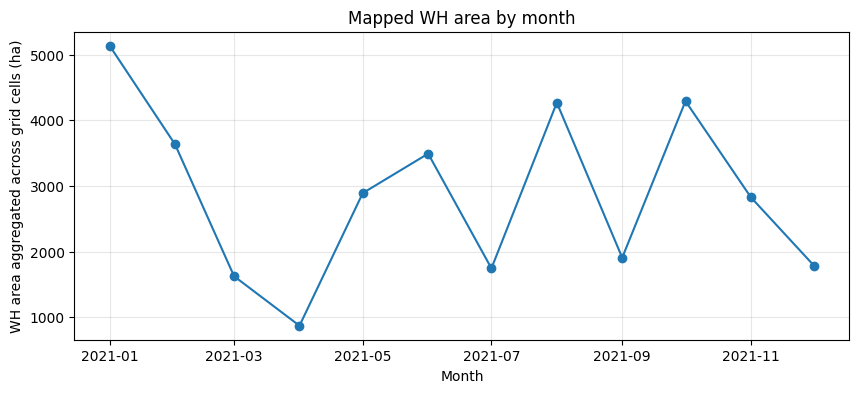

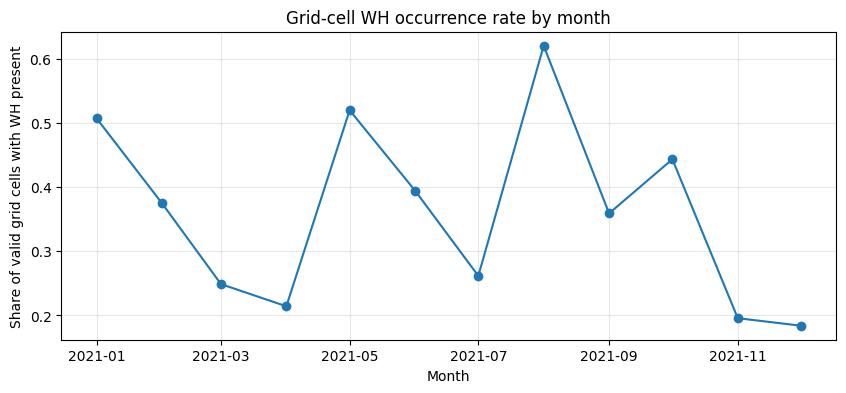

Overall share of cell-months with WH present: 0.3606


In [14]:
monthly_summary = (
    panel.groupby("month", as_index=False)
    .agg(
        wh_area_ha=("wh_area_ha", "sum"),
        valid_area_ha=("valid_area_ha", "sum"),
        mean_cover=("wh_cover", "mean"),
        occurrence_rate=("wh_present", "mean"),
        n_cells=("grid_id", "nunique"),
    )
)

display(monthly_summary)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(monthly_summary["month"], monthly_summary["wh_area_ha"], marker="o")
ax.set_title("Mapped WH area by month")
ax.set_xlabel("Month")
ax.set_ylabel("WH area aggregated across grid cells (ha)")
ax.grid(True, alpha=0.3)
plt.show()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(monthly_summary["month"], monthly_summary["occurrence_rate"], marker="o")
ax.set_title("Grid-cell WH occurrence rate by month")
ax.set_xlabel("Month")
ax.set_ylabel("Share of valid grid cells with WH present")
ax.grid(True, alpha=0.3)
plt.show()

print("Overall share of cell-months with WH present:", round(panel["wh_present"].mean(), 4))

## Methodological note: presence definition and probability threshold

The previous model used any non-zero WH area to define presence and used a fixed
0.5 probability threshold. This caused the presence model to be highly
conservative: precision was high but recall was very low, so the model missed
most true WH-present cells and underestimated total WH area. The updated workflow
tests a more ecologically meaningful presence threshold and tunes the probability
threshold using validation data.

Concretely, the changes below:

- define presence with a configurable cover/area threshold instead of "any pixel";
- split the existing training period into fitting and validation months and keep
  the original test months untouched;
- tune the presence probability threshold on the validation months (maximising F1
  by default, with a higher-recall option reported);
- form the final predicted WH area as a two-stage hurdle: the positive-cover model
  is applied only to cells predicted present at the tuned threshold, and zero cover
  is assigned to predicted-absent cells.


## Habitat / valid-cell filter

The panel can contain background cells and cell-months with very few valid
pixels, which dilute presence and push the classifier toward always predicting
absence. The filters below are applied conservatively before modelling:

- the existing minimum valid-pixel filter is retained;
- an optional minimum valid-fraction filter (off by default);
- an optional "ever validly observed" cell filter that keeps only cells with at
  least one valid observation across the panel.

No shoreline/littoral mask is invented here. The number of rows and unique cells
removed by each filter is printed.


In [ ]:
n_rows_before_filter = len(panel)
n_cells_before_filter = panel["grid_id"].nunique()
print(f"Before habitat/valid-cell filters: {n_rows_before_filter:,} rows, "
      f"{n_cells_before_filter:,} unique cells")

# 1. Minimum valid pixels per cell-month (already applied in section 7).
#    Re-assert here so the filter is explicit and its effect is reported.
before_rows, before_cells = len(panel), panel["grid_id"].nunique()
panel = panel[panel["valid_pixels"] >= MIN_VALID_PIXELS_PER_CELL_MONTH].copy()
print(f"[valid-pixel >= {MIN_VALID_PIXELS_PER_CELL_MONTH}] removed "
      f"{before_rows - len(panel):,} rows, {before_cells - panel['grid_id'].nunique():,} cells")

# 2. Optional minimum valid fraction per cell-month.
if MIN_VALID_FRACTION_PER_CELL_MONTH is not None and "valid_fraction" in panel.columns:
    before_rows, before_cells = len(panel), panel["grid_id"].nunique()
    panel = panel[panel["valid_fraction"] >= MIN_VALID_FRACTION_PER_CELL_MONTH].copy()
    print(f"[valid-fraction >= {MIN_VALID_FRACTION_PER_CELL_MONTH}] removed "
          f"{before_rows - len(panel):,} rows, {before_cells - panel['grid_id'].nunique():,} cells")
else:
    print("[valid-fraction] filter disabled (MIN_VALID_FRACTION_PER_CELL_MONTH is None)")

# 3. Optional "ever validly observed" cell filter.
#    Conservative: keep cells with at least one valid observation across the panel.
#    With only a classified/no-data validity flag available this is near-universal;
#    it is a scaffold for a stronger habitat mask if an ever-wet indicator is added.
if REQUIRE_EVER_WET_OR_EVER_OBSERVED:
    before_rows, before_cells = len(panel), panel["grid_id"].nunique()
    ever_valid_cells = (
        panel.loc[panel["valid_pixels"] >= MIN_VALID_PIXELS_PER_CELL_MONTH, "grid_id"].unique()
    )
    panel = panel[panel["grid_id"].isin(ever_valid_cells)].copy()
    print(f"[ever validly observed] removed "
          f"{before_rows - len(panel):,} rows, {before_cells - panel['grid_id'].nunique():,} cells")
else:
    print("[ever validly observed] filter disabled (REQUIRE_EVER_WET_OR_EVER_OBSERVED is False)")

print(f"After habitat/valid-cell filters: {len(panel):,} rows, "
      f"{panel['grid_id'].nunique():,} unique cells "
      f"(removed {n_rows_before_filter - len(panel):,} rows, "
      f"{n_cells_before_filter - panel['grid_id'].nunique():,} cells overall)")


## 12. Prepare model dataset

This model is intentionally simple and robust for a test period.

It uses a **temporally blocked train/test split**, rather than a random split, because random splitting would leak information from adjacent months into the test set.

Feature columns now include the Earth Engine and CSV covariates (and their one-month lags for the time-varying ones). Rows are dropped only when the **response** or the **structural lag features** are missing; missing values in the environmental covariates themselves (for example a cloudy Sentinel-2 month, or a cell that is mostly land) are left in place and imputed inside the model pipeline, so adding many covariates does not shrink the panel.

In [15]:
# Candidate model features.
candidate_features = [
    "month_sin",
    "month_cos",
    "time_index",
    "x_km",
    "y_km",
    "wh_cover_lag1",
    "wh_present_lag1",
]

# Time-varying covariates and their one-month lags.
candidate_features += time_varying_cols
candidate_features += [f"{c}_lag1" for c in time_varying_cols if f"{c}_lag1" in panel.columns]

# Static spatial covariates (no lag).
candidate_features += static_cols

feature_cols = clean_feature_columns(panel, candidate_features)

print(f"Model feature columns ({len(feature_cols)}):")
for c in feature_cols:
    print(" -", c)

model_df = panel.dropna(subset=["wh_cover", "wh_present"]).copy()

# Drop rows only when the response or the structural lag features are missing.
# For a very short test period this may remove the first month (lag1 is NaN there).
# Environmental covariates are intentionally NOT in this list: their missing
# values are imputed inside the model pipeline (median imputer), so adding many
# sparse covariates (e.g. cloudy Sentinel-2 months) does not collapse the panel.
structural_required = [
    "wh_cover", "wh_present", "grid_id", "month", "valid_area_m2",
    "wh_cover_lag1", "wh_present_lag1",
]
structural_required = [c for c in structural_required if c in model_df.columns]
model_df = model_df.dropna(subset=structural_required).copy()

if len(model_df) == 0:
    raise RuntimeError("No model rows remain after dropping missing response/lag values.")

months_sorted = np.array(sorted(model_df["month"].unique()))
split_idx = max(1, int(len(months_sorted) * TRAIN_FRACTION))
split_month = months_sorted[split_idx]

train = model_df[model_df["month"] < split_month].copy()
test = model_df[model_df["month"] >= split_month].copy()

# Split the TRAIN period into fitting and validation months. The validation
# months are used only to tune the presence probability threshold; the TEST
# months are never used for tuning and remain unchanged.
train_months = np.array(sorted(train["month"].unique()))
if len(train_months) > 1:
    n_val_months = int(round(len(train_months) * VALIDATION_FRACTION))
    n_val_months = max(1, min(n_val_months, len(train_months) - 1))
else:
    n_val_months = 0

if n_val_months > 0:
    val_months = train_months[-n_val_months:]
    fit_months = train_months[:-n_val_months]
else:
    val_months = np.array([], dtype=train_months.dtype)
    fit_months = train_months

train_fit = train[train["month"].isin(fit_months)].copy()
train_val = train[train["month"].isin(val_months)].copy()

print(
    f"Fitting months:    {pd.Timestamp(fit_months.min()).date()} to {pd.Timestamp(fit_months.max()).date()}"
    if len(fit_months) else "Fitting months:    (none)"
)
print(
    f"Validation months: {pd.Timestamp(val_months.min()).date()} to {pd.Timestamp(val_months.max()).date()}"
    if len(val_months) else "Validation months: (none - threshold tuning falls back to training)"
)
print(f"Testing months:    {test['month'].min().date()} to {test['month'].max().date()}")
print(f"Fit rows: {len(train_fit):,} | Val rows: {len(train_val):,} | "
      f"Train(total) rows: {len(train):,} | Test rows: {len(test):,}")
print(f"Train WH-present rate: {train['wh_present'].mean():.4f}")
print(f"Val   WH-present rate: {train_val['wh_present'].mean():.4f}" if len(train_val) else "Val   WH-present rate: (n/a)")
print(f"Test  WH-present rate: {test['wh_present'].mean():.4f}")

X_train = train[feature_cols]
X_test = test[feature_cols]
X_fit = train_fit[feature_cols]
X_val = train_val[feature_cols]

y_train_presence = train["wh_present"].astype(int)
y_test_presence = test["wh_present"].astype(int)
y_fit_presence = train_fit["wh_present"].astype(int)
y_val_presence = train_val["wh_present"].astype(int)

Model feature columns (45):
 - month_sin
 - month_cos
 - time_index
 - x_km
 - y_km
 - wh_cover_lag1
 - wh_present_lag1
 - air_temp_c
 - rain_chirps_30d_mm
 - rain_chirps_90d_mm
 - rain_chirps_mm
 - water_temp_c
 - wind_speed_ms
 - wind_u_ms
 - wind_v_ms
 - wind_dir_to_deg
 - wind_axis_comp_ms
 - wind_cross_comp_ms
 - red_reflectance_s2
 - turb_ndti_s2
 - chl_mci_s3
 - chl_mph_s3
 - air_temp_c_lag1
 - rain_chirps_30d_mm_lag1
 - rain_chirps_90d_mm_lag1
 - rain_chirps_mm_lag1
 - water_temp_c_lag1
 - wind_speed_ms_lag1
 - wind_u_ms_lag1
 - wind_v_ms_lag1
 - wind_dir_to_deg_lag1
 - wind_axis_comp_ms_lag1
 - wind_cross_comp_ms_lag1
 - red_reflectance_s2_lag1
 - turb_ndti_s2_lag1
 - chl_mci_s3_lag1
 - chl_mph_s3_lag1
 - dist_river_m
 - dist_shore_m
 - openness_index
 - frac_cropland
 - frac_urban
 - frac_wetland
 - ghsl_built_m2
 - pop_count
Training months: 2021-02-01 to 2021-09-01
Testing months:  2021-10-01 to 2021-12-01
Train rows: 86,601
Test rows:  32,478
Train WH-present rate: 0.3744


## 13. Stage 1 model: WH presence/absence

This estimates whether each grid cell contains any mapped WH in each month.

For the final dissertation, you may want to compare this with a GAM, GLMM or Bayesian model. This notebook uses regularised logistic regression because it is fast, transparent and easy to test.

In [16]:
if y_train_presence.nunique() < 2:
    raise RuntimeError(
        "The training set contains only one presence/absence class. "
        "Try a longer test period, larger AOI, different class codes, or coarser grid."
    )


def find_best_threshold(y_true, y_prob, metric="f1"):
    """Sweep probability thresholds in [0.01, 0.99] and pick the best by ``metric``.

    Returns (best, sweep):
      - best:  pandas Series with threshold, precision, recall, f1, pred_pos_rate
      - sweep: DataFrame of those metrics across all thresholds
    """
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob, dtype=float)
    thresholds = np.round(np.arange(0.01, 0.991, 0.01), 2)
    rows = []
    for t in thresholds:
        pred = (y_prob >= t).astype(int)
        rows.append({
            "threshold": t,
            "precision": precision_score(y_true, pred, zero_division=0),
            "recall": recall_score(y_true, pred, zero_division=0),
            "f1": f1_score(y_true, pred, zero_division=0),
            "pred_pos_rate": float(pred.mean()),
        })
    sweep = pd.DataFrame(rows)
    score_col = metric if metric in {"f1", "precision", "recall"} else "f1"
    best = sweep.loc[sweep[score_col].idxmax()].copy()
    return best, sweep


presence_model = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    )),
])

# --- Tune the presence probability threshold ---------------------------------
# Preferred: fit on the fitting months and select the threshold on the held-out
# validation months. If the validation block is degenerate (empty or single
# class), fall back to tuning on the training predictions and label it OPTIMISTIC.
use_validation = (
    len(train_val) > 0
    and y_val_presence.nunique() == 2
    and len(train_fit) > 0
    and y_fit_presence.nunique() == 2
)

if use_validation:
    presence_model.fit(X_fit, y_fit_presence)
    val_presence_prob = presence_model.predict_proba(X_val)[:, 1]
    best_threshold_row, threshold_sweep = find_best_threshold(
        y_val_presence, val_presence_prob, metric=PRESENCE_THRESHOLD_METRIC
    )
    threshold_source = "validation months"
else:
    presence_model.fit(X_train, y_train_presence)
    train_presence_prob = presence_model.predict_proba(X_train)[:, 1]
    best_threshold_row, threshold_sweep = find_best_threshold(
        y_train_presence, train_presence_prob, metric=PRESENCE_THRESHOLD_METRIC
    )
    threshold_source = "training predictions (OPTIMISTIC: no usable validation block)"

selected_threshold = float(best_threshold_row["threshold"])

# Higher-recall alternative: highest-recall threshold whose precision stays above
# PRESENCE_MIN_PRECISION_FOR_RECALL.
acceptable = threshold_sweep[threshold_sweep["precision"] >= PRESENCE_MIN_PRECISION_FOR_RECALL]
if len(acceptable) > 0:
    high_recall_row = acceptable.sort_values(["recall", "threshold"], ascending=[False, True]).iloc[0]
else:
    high_recall_row = None

# --- Final model: refit on the full training period --------------------------
presence_model.fit(X_train, y_train_presence)
test_presence_prob = presence_model.predict_proba(X_test)[:, 1]
test_presence_pred = test_presence_prob >= selected_threshold      # tuned threshold
test_presence_pred_05 = test_presence_prob >= 0.5                  # legacy threshold

print(f"Threshold tuned on: {threshold_source}")
print(f"Selected probability threshold ({PRESENCE_THRESHOLD_METRIC}-optimal): {selected_threshold:.2f}")
print(f"  validation precision={best_threshold_row['precision']:.3f} "
      f"recall={best_threshold_row['recall']:.3f} f1={best_threshold_row['f1']:.3f} "
      f"pred_pos_rate={best_threshold_row['pred_pos_rate']:.3f}")
if high_recall_row is not None:
    print(f"Higher-recall option (precision >= {PRESENCE_MIN_PRECISION_FOR_RECALL}): "
          f"threshold={high_recall_row['threshold']:.2f} "
          f"precision={high_recall_row['precision']:.3f} "
          f"recall={high_recall_row['recall']:.3f} f1={high_recall_row['f1']:.3f}")
else:
    print(f"No threshold kept precision >= {PRESENCE_MIN_PRECISION_FOR_RECALL}; "
          f"using the {PRESENCE_THRESHOLD_METRIC}-optimal threshold only.")

print(f"\nPresence/absence classification report (TEST, tuned threshold = {selected_threshold:.2f}):")
print(classification_report(y_test_presence, test_presence_pred, digits=3))

print("Presence/absence classification report (TEST, legacy threshold = 0.50):")
print(classification_report(y_test_presence, test_presence_pred_05, digits=3))

if y_test_presence.nunique() == 2:
    print("ROC AUC:", round(roc_auc_score(y_test_presence, test_presence_prob), 4))
    print("Average precision (PR AUC):", round(average_precision_score(y_test_presence, test_presence_prob), 4))
    print("Brier score:", round(brier_score_loss(y_test_presence, test_presence_prob), 4))
else:
    print("Test set contains only one class, so ROC AUC and average precision are undefined.")

presence_coef = pd.DataFrame({
    "feature": feature_cols,
    "standardised_logit_coefficient": presence_model.named_steps["model"].coef_[0],
}).sort_values("standardised_logit_coefficient", key=np.abs, ascending=False)

display(presence_coef)

Presence/absence classification report:
              precision    recall  f1-score   support

           0      0.747     0.994     0.853     23563
           1      0.871     0.108     0.193      8915

    accuracy                          0.751     32478
   macro avg      0.809     0.551     0.523     32478
weighted avg      0.781     0.751     0.672     32478

ROC AUC: 0.7219
Average precision: 0.5611
Brier score: 0.1918


,feature,standardised_logit_coefficient
22,air_temp_c_lag1,-1.035258
1,month_cos,-0.660330
11,water_temp_c,-0.622676
7,air_temp_c,0.537864
23,rain_chirps_30d_mm_lag1,-0.477484
43,ghsl_built_m2,0.439458
15,wind_dir_to_deg,-0.418912
39,openness_index,-0.408833
31,wind_axis_comp_ms_lag1,0.395733
28,wind_u_ms_lag1,0.395733


### Presence model diagnostics

Fuller diagnostics for the presence stage: confusion matrix, predicted positive
rates at the legacy (0.5) and tuned thresholds, precision/recall/F1 at the
selected threshold, and the distribution of predicted probabilities for truly
absent vs truly present test cells.


In [ ]:
print("Selected threshold:", round(selected_threshold, 2), f"(tuned on {threshold_source})")

if y_test_presence.nunique() == 2:
    print("ROC AUC:", round(roc_auc_score(y_test_presence, test_presence_prob), 4))
    print("PR AUC (average precision):", round(average_precision_score(y_test_presence, test_presence_prob), 4))
else:
    print("ROC AUC / PR AUC: undefined (single class in test).")

print("\nConfusion matrix (TEST, tuned threshold); rows=observed, cols=predicted:")
cm = confusion_matrix(y_test_presence, test_presence_pred, labels=[0, 1])
display(pd.DataFrame(cm, index=["obs_absent", "obs_present"],
                     columns=["pred_absent", "pred_present"]))

obs_pos_rate = float(y_test_presence.mean())
pred_pos_rate_05 = float(np.mean(test_presence_pred_05))
pred_pos_rate_tuned = float(np.mean(test_presence_pred))
prec_t = precision_score(y_test_presence, test_presence_pred, zero_division=0)
rec_t = recall_score(y_test_presence, test_presence_pred, zero_division=0)
f1_t = f1_score(y_test_presence, test_presence_pred, zero_division=0)

print(f"\nObserved positive rate (TEST):              {obs_pos_rate:.4f}")
print(f"Predicted positive rate @0.50:              {pred_pos_rate_05:.4f}")
print(f"Predicted positive rate @{selected_threshold:.2f} (tuned):       {pred_pos_rate_tuned:.4f}")
print(f"TEST precision/recall/F1 @ tuned threshold: {prec_t:.3f} / {rec_t:.3f} / {f1_t:.3f}")

# Distribution of predicted probabilities by true class.
prob_absent = test_presence_prob[y_test_presence.values == 0]
prob_present = test_presence_prob[y_test_presence.values == 1]

quantiles = [0.0, 0.1, 0.25, 0.5, 0.75, 0.9, 1.0]
prob_quantile_table = pd.DataFrame({
    "quantile": quantiles,
    "prob_true_absent": [np.quantile(prob_absent, q) if len(prob_absent) else np.nan for q in quantiles],
    "prob_true_present": [np.quantile(prob_present, q) if len(prob_present) else np.nan for q in quantiles],
})
print("\nPredicted-probability quantiles by true class (TEST):")
display(prob_quantile_table)

fig, ax = plt.subplots(figsize=(8, 4))
bins = np.linspace(0, 1, 21)
if len(prob_absent):
    ax.hist(prob_absent, bins=bins, alpha=0.5, density=True, label="True absent")
if len(prob_present):
    ax.hist(prob_present, bins=bins, alpha=0.5, density=True, label="True present")
ax.axvline(0.5, color="grey", linestyle=":", label="0.50 (legacy)")
ax.axvline(selected_threshold, color="red", linestyle="--", label=f"{selected_threshold:.2f} (tuned)")
ax.set_title("Predicted presence probability by true class (TEST)")
ax.set_xlabel("Predicted probability of WH presence")
ax.set_ylabel("Density")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

print("Threshold sweep (validation/optimistic), every 5th row:")
display(threshold_sweep.iloc[::5].reset_index(drop=True))


## 14. Stage 2 model: WH cover where present

This estimates proportional WH cover for cell-months where WH is present.

The response is logit-transformed WH cover. Predictions are converted back to proportional cover.

In [18]:
def logit_clip(x, eps=1e-5):
    x = np.clip(np.asarray(x, dtype=float), eps, 1 - eps)
    return np.log(x / (1 - x))


def inv_logit(z):
    return 1 / (1 + np.exp(-z))


positive_train = train[train["wh_present"]].copy()
positive_test = test[test["wh_present"]].copy()

if len(positive_train) < 10:
    raise RuntimeError(
        "Too few positive WH training rows for the cover model. "
        "Try a longer period, larger AOI, coarser grid, or check WH_CLASS_VALUES."
    )

X_train_cover = positive_train[feature_cols]
y_train_cover = logit_clip(positive_train["wh_cover"])

cover_model = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0, random_state=RANDOM_STATE)),
])

cover_model.fit(X_train_cover, y_train_cover)

# Conditional cover predictions for all test rows.
test_cover_logit_pred = cover_model.predict(X_test)
test_cover_conditional_pred = inv_logit(test_cover_logit_pred)

# Evaluate only where WH was truly present.
if len(positive_test) > 0:
    X_pos_test = positive_test[feature_cols]
    pos_pred = inv_logit(cover_model.predict(X_pos_test))

    rmse = np.sqrt(mean_squared_error(positive_test["wh_cover"], pos_pred))
    mae = mean_absolute_error(positive_test["wh_cover"], pos_pred)

    print("Positive-cover model performance, evaluated only where WH is observed present:")
    print("RMSE:", round(rmse, 4))
    print("MAE: ", round(mae, 4))
else:
    print("No positive WH rows in test set, so positive-cover performance is undefined.")

cover_coef = pd.DataFrame({
    "feature": feature_cols,
    "standardised_cover_coefficient": cover_model.named_steps["model"].coef_,
}).sort_values("standardised_cover_coefficient", key=np.abs, ascending=False)

display(cover_coef)

Positive-cover model performance, evaluated only where WH is observed present:
RMSE: 0.1653
MAE:  0.1062


,feature,standardised_cover_coefficient
1,month_cos,-0.828903
5,wh_cover_lag1,0.776224
33,red_reflectance_s2_lag1,-0.638405
2,time_index,0.626998
22,air_temp_c_lag1,-0.599389
7,air_temp_c,0.538613
0,month_sin,-0.529950
31,wind_axis_comp_ms_lag1,0.509230
28,wind_u_ms_lag1,0.509230
19,turb_ndti_s2,0.482692


## 15. Combined expected-cover predictions

The two stages are combined as:

`expected WH cover = probability of WH presence × conditional WH cover`

This is useful for estimating expected WH area in each grid cell and month.

,grid_id,month,valid_area_m2,wh_area_m2,wh_area_ha,wh_cover,wh_present,pred_presence_prob,pred_cover_if_present,pred_expected_cover,pred_wh_area_m2,pred_wh_area_ha
9,0,2021-10-01,71300.000000,0.0,0.0,0.0,False,0.057506,0.002351,0.000135,9.639392,0.000964
10,0,2021-11-01,71133.333333,0.0,0.0,0.0,False,0.039010,0.001377,0.000054,3.819968,0.000382
11,0,2021-12-01,71300.000000,0.0,0.0,0.0,False,0.051652,0.011945,0.000617,43.991485,0.004399
21,1,2021-10-01,115000.000000,0.0,0.0,0.0,False,0.054474,0.002185,0.000119,13.690546,0.001369
22,1,2021-11-01,115000.000000,0.0,0.0,0.0,False,0.041107,0.001440,0.000059,6.807724,0.000681


,month,observed_wh_area_ha,predicted_wh_area_ha,observed_mean_cover,predicted_mean_cover
0,2021-10-01,4291.075833,74.964063,0.053576,0.002512
1,2021-11-01,2825.830000,61.084341,0.025503,0.001684
2,2021-12-01,1781.245000,1051.565463,0.022521,0.011438


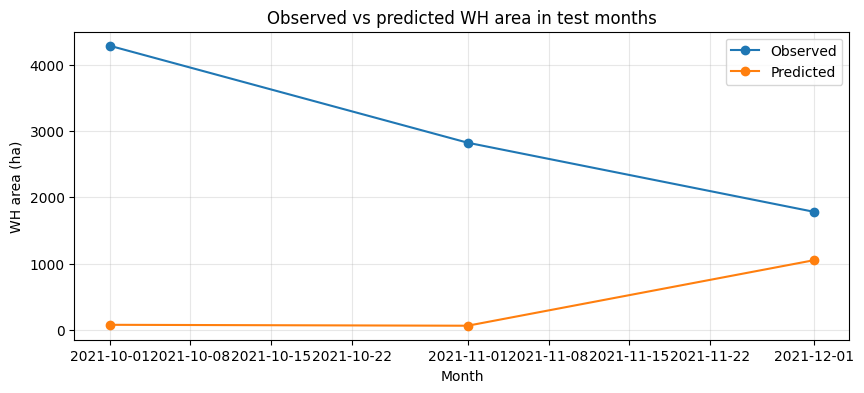

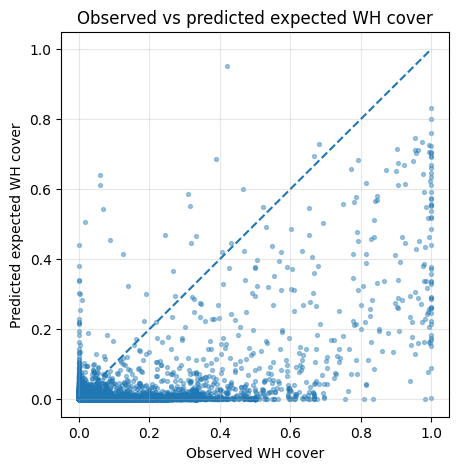

In [19]:
test_preds = test[[
    "grid_id", "month", "valid_area_m2", "wh_area_m2", "wh_area_ha",
    "wh_cover", "wh_present"
]].copy()

test_preds["pred_presence_prob"] = test_presence_prob
test_preds["pred_cover_if_present"] = test_cover_conditional_pred
test_preds["pred_expected_cover"] = (
    test_preds["pred_presence_prob"] * test_preds["pred_cover_if_present"]
)
test_preds["pred_wh_area_m2"] = test_preds["pred_expected_cover"] * test_preds["valid_area_m2"]
test_preds["pred_wh_area_ha"] = test_preds["pred_wh_area_m2"] / 10_000

# --- Two-stage hurdle predictions --------------------------------------------
# Final hurdle: apply the conditional cover model only where presence is predicted
# at the given threshold, and assign zero cover to predicted-absent cells.
test_preds["pred_present_05"] = (test_preds["pred_presence_prob"] >= 0.5).astype(int)
test_preds["pred_present_tuned"] = (test_preds["pred_presence_prob"] >= selected_threshold).astype(int)

test_preds["pred_wh_area_ha_hurdle_05"] = np.where(
    test_preds["pred_present_05"] == 1,
    test_preds["pred_cover_if_present"] * test_preds["valid_area_m2"] / 10_000,
    0.0,
)
test_preds["pred_wh_area_ha_hurdle_tuned"] = np.where(
    test_preds["pred_present_tuned"] == 1,
    test_preds["pred_cover_if_present"] * test_preds["valid_area_m2"] / 10_000,
    0.0,
)

display(test_preds.head())

monthly_pred_summary = (
    test_preds.groupby("month", as_index=False)
    .agg(
        observed_wh_area_ha=("wh_area_ha", "sum"),
        predicted_wh_area_ha=("pred_wh_area_ha", "sum"),
        observed_mean_cover=("wh_cover", "mean"),
        predicted_mean_cover=("pred_expected_cover", "mean"),
    )
)

display(monthly_pred_summary)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(monthly_pred_summary["month"], monthly_pred_summary["observed_wh_area_ha"], marker="o", label="Observed")
ax.plot(monthly_pred_summary["month"], monthly_pred_summary["predicted_wh_area_ha"], marker="o", label="Predicted")
ax.set_title("Observed vs predicted WH area in test months")
ax.set_xlabel("Month")
ax.set_ylabel("WH area (ha)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(test_preds["wh_cover"], test_preds["pred_expected_cover"], s=8, alpha=0.4)
ax.plot([0, 1], [0, 1], linestyle="--")
ax.set_title("Observed vs predicted expected WH cover")
ax.set_xlabel("Observed WH cover")
ax.set_ylabel("Predicted expected WH cover")
ax.grid(True, alpha=0.3)
plt.show()

### Test-month area comparison: legacy 0.5 vs tuned threshold

Observed WH area per test month compared with the hurdle prediction using the
legacy 0.5 threshold and the tuned threshold, with absolute and percentage
errors. This shows whether threshold tuning reduces the severe under-prediction
in the later test months.


In [ ]:
area_compare = (
    test_preds.groupby("month", as_index=False)
    .agg(
        observed_wh_area_ha=("wh_area_ha", "sum"),
        pred_area_ha_05=("pred_wh_area_ha_hurdle_05", "sum"),
        pred_area_ha_tuned=("pred_wh_area_ha_hurdle_tuned", "sum"),
    )
)


def _pct_err(pred, obs):
    return np.where(obs > 0, 100.0 * (pred - obs) / obs, np.nan)


area_compare["abs_err_05_ha"] = (area_compare["pred_area_ha_05"] - area_compare["observed_wh_area_ha"]).abs()
area_compare["pct_err_05"] = _pct_err(area_compare["pred_area_ha_05"].values, area_compare["observed_wh_area_ha"].values)
area_compare["abs_err_tuned_ha"] = (area_compare["pred_area_ha_tuned"] - area_compare["observed_wh_area_ha"]).abs()
area_compare["pct_err_tuned"] = _pct_err(area_compare["pred_area_ha_tuned"].values, area_compare["observed_wh_area_ha"].values)

# Rounded copy for display.
area_compare_display = area_compare.copy()
for c in ["observed_wh_area_ha", "pred_area_ha_05", "pred_area_ha_tuned", "abs_err_05_ha", "abs_err_tuned_ha"]:
    area_compare_display[c] = area_compare_display[c].round(2)
for c in ["pct_err_05", "pct_err_tuned"]:
    area_compare_display[c] = area_compare_display[c].round(1)

print("Test-month WH area: observed vs hurdle predictions (0.5 vs tuned threshold)")
display(area_compare_display)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(area_compare["month"], area_compare["observed_wh_area_ha"], marker="o", label="Observed")
ax.plot(area_compare["month"], area_compare["pred_area_ha_05"], marker="o", label="Predicted (hurdle @0.5)")
ax.plot(area_compare["month"], area_compare["pred_area_ha_tuned"], marker="o",
        label=f"Predicted (hurdle @{selected_threshold:.2f})")
ax.set_title("Observed vs hurdle-predicted WH area by test month")
ax.set_xlabel("Month")
ax.set_ylabel("WH area (ha)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

print(f"Test-period totals (ha): observed={area_compare['observed_wh_area_ha'].sum():.1f}, "
      f"hurdle@0.5={area_compare['pred_area_ha_05'].sum():.1f}, "
      f"hurdle@tuned={area_compare['pred_area_ha_tuned'].sum():.1f}")


## 16. Map mean observed WH cover by grid cell

This checks whether the spatial pattern looks ecologically sensible.

Cells with consistently high cover should generally correspond to sheltered littoral/embayment zones if the classification and grid design are working.

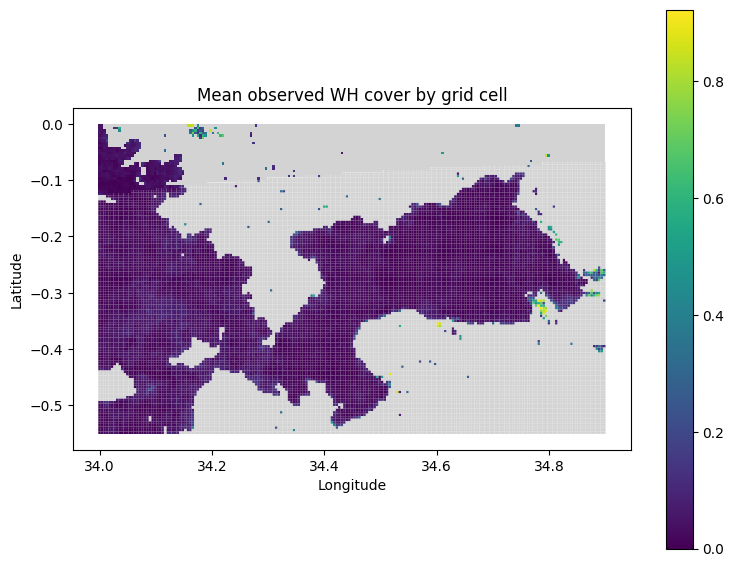

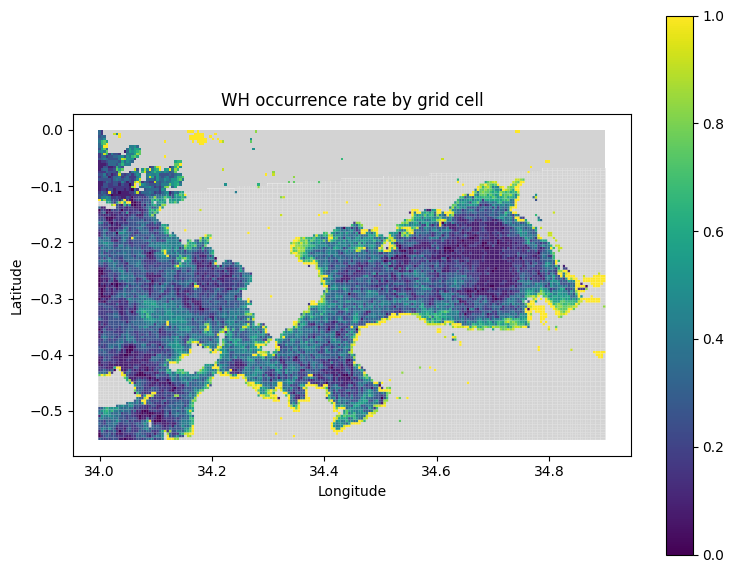

In [20]:
cell_summary = (
    panel.groupby("grid_id", as_index=False)
    .agg(
        mean_wh_cover=("wh_cover", "mean"),
        max_wh_cover=("wh_cover", "max"),
        occurrence_rate=("wh_present", "mean"),
        mean_wh_area_ha=("wh_area_ha", "mean"),
        n_months=("month", "nunique"),
    )
)

grid_summary = grid.merge(cell_summary, on="grid_id", how="left")

ax = grid_summary.to_crs("EPSG:4326").plot(
    column="mean_wh_cover",
    figsize=(9, 7),
    legend=True,
    missing_kwds={"color": "lightgrey", "label": "No valid observations"},
)
ax.set_title("Mean observed WH cover by grid cell")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.show()

ax = grid_summary.to_crs("EPSG:4326").plot(
    column="occurrence_rate",
    figsize=(9, 7),
    legend=True,
    missing_kwds={"color": "lightgrey", "label": "No valid observations"},
)
ax.set_title("WH occurrence rate by grid cell")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.show()

## 17. Export outputs

In addition to the panel, predictions, monthly summary, coefficients and grid summary, the raw Earth Engine covariate tables (`ee_monthly_cov`, `ee_cellmonth_cov`, `ee_static_cov`) are saved when they were produced, so the extracted drivers can be inspected or reused without re-querying Earth Engine.

In [21]:
panel_csv = OUTPUT_DIR / f"wh_spatial_panel_{CELL_SIZE_M}m_{TEST_START}_to_{TEST_END}.csv"
test_preds_csv = OUTPUT_DIR / f"wh_spatial_panel_predictions_{CELL_SIZE_M}m_{TEST_START}_to_{TEST_END}.csv"
monthly_summary_csv = OUTPUT_DIR / f"wh_monthly_summary_{CELL_SIZE_M}m_{TEST_START}_to_{TEST_END}.csv"
coef_csv = OUTPUT_DIR / f"wh_model_coefficients_{CELL_SIZE_M}m_{TEST_START}_to_{TEST_END}.csv"
grid_summary_gpkg = OUTPUT_DIR / f"wh_grid_summary_{CELL_SIZE_M}m_{TEST_START}_to_{TEST_END}.gpkg"

panel.to_csv(panel_csv, index=False)
test_preds.to_csv(test_preds_csv, index=False)
monthly_summary.to_csv(monthly_summary_csv, index=False)

coef_out = presence_coef.merge(cover_coef, on="feature", how="outer")
coef_out.to_csv(coef_csv, index=False)

grid_summary.to_file(grid_summary_gpkg, layer="grid_summary", driver="GPKG")

saved_paths = [panel_csv, test_preds_csv, monthly_summary_csv, coef_csv, grid_summary_gpkg]

# Also save the raw Earth Engine covariate tables when they were produced.
ee_covariate_tables = {
    "ee_monthly_covariates": ee_monthly_cov,
    "ee_cellmonth_covariates": ee_cellmonth_cov,
    "ee_static_covariates": ee_static_cov,
}
for name, table in ee_covariate_tables.items():
    if table is not None and len(table) > 0:
        out_csv = OUTPUT_DIR / f"{name}_{CELL_SIZE_M}m_{TEST_START}_to_{TEST_END}.csv"
        table.to_csv(out_csv, index=False)
        saved_paths.append(out_csv)

print("Saved:")
for p in saved_paths:
    print(p)

Saved:
/content/drive/MyDrive/WH_spatial_panel_test/wh_spatial_panel_500m_2021-01-01_to_2021-12-31.csv
/content/drive/MyDrive/WH_spatial_panel_test/wh_spatial_panel_predictions_500m_2021-01-01_to_2021-12-31.csv
/content/drive/MyDrive/WH_spatial_panel_test/wh_monthly_summary_500m_2021-01-01_to_2021-12-31.csv
/content/drive/MyDrive/WH_spatial_panel_test/wh_model_coefficients_500m_2021-01-01_to_2021-12-31.csv
/content/drive/MyDrive/WH_spatial_panel_test/wh_grid_summary_500m_2021-01-01_to_2021-12-31.gpkg
/content/drive/MyDrive/WH_spatial_panel_test/ee_monthly_covariates_500m_2021-01-01_to_2021-12-31.csv
/content/drive/MyDrive/WH_spatial_panel_test/ee_cellmonth_covariates_500m_2021-01-01_to_2021-12-31.csv
/content/drive/MyDrive/WH_spatial_panel_test/ee_static_covariates_500m_2021-01-01_to_2021-12-31.csv


## Model diagnosis after threshold and target-definition changes

A concise summary of the presence-definition and threshold changes and their
effect on predicted WH extent.


In [ ]:
print("=" * 70)
print("MODEL DIAGNOSIS AFTER THRESHOLD AND TARGET-DEFINITION CHANGES")
print("=" * 70)

# 1. Presence definition.
print(f"\nPresence definition: {presence_definition}")

# 2. Selected probability threshold.
print(f"Selected probability threshold: {selected_threshold:.2f} "
      f"(metric={PRESENCE_THRESHOLD_METRIC}, tuned on {threshold_source})")


# 3. Train / validation / test months.
def _months_range(arr):
    arr = list(arr)
    if len(arr) == 0:
        return "(none)"
    return f"{pd.Timestamp(min(arr)).date()} to {pd.Timestamp(max(arr)).date()} ({len(arr)} months)"


print(f"\nFitting months:    {_months_range(fit_months)}")
print(f"Validation months: {_months_range(val_months)}")
print(f"Test months:       {_months_range(test['month'].unique())}")

# 4. Presence model precision / recall / F1 on TEST.
prec_t = precision_score(y_test_presence, test_presence_pred, zero_division=0)
rec_t = recall_score(y_test_presence, test_presence_pred, zero_division=0)
f1_t = f1_score(y_test_presence, test_presence_pred, zero_division=0)
prec_0 = precision_score(y_test_presence, test_presence_pred_05, zero_division=0)
rec_0 = recall_score(y_test_presence, test_presence_pred_05, zero_division=0)
f1_0 = f1_score(y_test_presence, test_presence_pred_05, zero_division=0)
print(f"\nPresence model (TEST) @ tuned {selected_threshold:.2f}: "
      f"precision={prec_t:.3f}, recall={rec_t:.3f}, F1={f1_t:.3f}")
print(f"Presence model (TEST) @ legacy 0.50: "
      f"precision={prec_0:.3f}, recall={rec_0:.3f}, F1={f1_0:.3f}")

# 5. Observed vs predicted area by test month.
print("\nTest-month observed vs predicted WH area (ha):")
display(area_compare_display)

# 6. Notes on whether the model still under-predicts.
obs_total = area_compare["observed_wh_area_ha"].sum()
pred_total_tuned = area_compare["pred_area_ha_tuned"].sum()
pred_total_05 = area_compare["pred_area_ha_05"].sum()
ratio_tuned = (pred_total_tuned / obs_total) if obs_total > 0 else np.nan
ratio_05 = (pred_total_05 / obs_total) if obs_total > 0 else np.nan

print("\nNotes:")
print(f"- Tuned threshold recovers {ratio_tuned:.0%} of observed test-period WH area "
      f"(legacy 0.5 recovered {ratio_05:.0%})." if np.isfinite(ratio_tuned)
      else "- Observed test-period WH area is zero, so recovery ratios are undefined.")
if np.isfinite(ratio_tuned) and ratio_tuned < 0.8:
    print("- The model still UNDER-predicts total WH extent (< 80% of observed). "
          "Consider a lower presence threshold, the higher-recall probability "
          "threshold, or additional habitat covariates.")
elif np.isfinite(ratio_tuned) and ratio_tuned > 1.2:
    print("- The model now OVER-predicts total WH extent (> 120% of observed). "
          "Consider a higher presence/probability threshold.")
else:
    print("- Total predicted WH extent is broadly consistent with observed (within +/-20%).")
print(f"- Presence recall changed from {rec_0:.2f} (legacy 0.5) to {rec_t:.2f} (tuned).")


## 18. Interpretation checklist

Use this checklist before treating the results as environmental inference.

### Raster/classification checks

- Confirm that `WH_CLASS_VALUES` correctly identifies water hyacinth.
- Inspect several classified rasters visually.
- Check that missing/cloudy months are not being interpreted as true WH absence.
- Compare S1-derived and S2-derived classifications separately if both are present.

### Earth Engine covariate checks

- Confirm Earth Engine initialised on the expected project (`EE_PROJECT`) and that section 8 reported the covariate columns you expected.
- The coarse climate layers (CHIRPS, ERA5, MODIS) are **AOI-mean monthly** values, so they vary in time but not between cells; treat them as regional forcing, not local gradients.
- Sentinel-2 turbidity (NDTI + red reflectance) is a **proxy**, not calibrated turbidity/TSS; cloudy months legitimately come back as missing and are imputed in the model.
- `water_temp_c` (MODIS LST over water) and the water-quality proxies are masked to JRC permanent water at `EE_WATER_OCCURRENCE_THRESHOLD`; cells that are mostly land will be missing.
- Chlorophyll-a now comes solely from Sentinel-3 OLCI (MCI/MPH). MODIS-Aqua chl-a is off by default (`chl_modis=False`; it ends 2022-02-28 and is unreliable in turbid inland water) and the Sentinel-2 NDCI chl-a proxy is off (`EE_S2_PRODUCTS={'turbidity'}`). Add 'chla' to EE_S2_PRODUCTS or set chl_modis=True to re-enable those cross-checks.
- Sentinel-3 chl-a (`chl_mci_s3`, `chl_mph_s3`) follows Kravitz et al. (2020): MCI/MPH band-difference algorithms on OLCI **TOA reflectance**, because GEE's OLCI asset lacks the geometry/meteorology needed for the paper's BRR/6SV corrections. The MPH calibration is BRR-derived applied to TOA reflectance, and none of the calibrations are tuned for Winam Gulf, so treat the mg/m³ values as indicative and locally re-calibrate against in-situ chl-a where possible.
- Check the bay-axis assumption: `EE_BAY_AXIS_BEARING_DEG` should match the orientation of the gulf you are modelling.

### Panel-design checks

- Test 500 m vs 1 km cells (1 km is much faster for the per-cell Earth Engine reductions).
- Consider restricting the grid to a littoral/water mask rather than the full bounding box.
- Avoid pixel-level modelling because this creates extreme pseudo-replication.
- Check whether high-cover cells correspond to plausible embayments, sheltered shores or river-mouth zones.

### Modelling checks

- Use temporally blocked validation.
- Consider spatially blocked validation for final results.
- Check autocorrelation in residuals.
- Check collinearity among rainfall, antecedent rainfall, turbidity, chlorophyll-a, temperature and lake level (the Earth Engine layers add several correlated predictors).
- Treat coefficients as associations, not proof of causation.
- For the final dissertation, consider a GAM, GLMM, hurdle model or Bayesian spatio-temporal model if time allows.

### Layers still to add from non-Earth-Engine sources

The Earth Engine extraction now covers rainfall, wind, temperature, water-quality proxies, river/shore geometry and catchment pressure. The remaining recommended drivers have no standard Earth Engine asset and should be supplied through `ENV_MONTHLY_CSV` / `SPATIAL_COVARIATES_CSV`:

- lake-level anomaly (DAHITI, Hydroweb, G-REALM or Jason/Sentinel altimetry);
- bathymetry/depth and a level–depth interaction (Lake Victoria bathymetry/DEM);
- ENSO/IOD indices (ONI/Niño 3.4, Dipole Mode Index) for temporal models;
- in-situ nutrients (TN, TP, DIN, SRP) as mechanistic/confounder variables.

Adding lake level and depth in particular would turn this from a mostly technical spatial-panel prototype into a genuinely ecological spatio-temporal model.

**Key references:** Kravitz et al. (2020), *Remote Sensing of Environment* 237:111562 (Sentinel-3 OLCI chl-a, atmospheric-correction comparison); Matthews et al. (2012), *Remote Sensing of Environment* 124:637–652 (MPH algorithm).